In [503]:
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt 
import scipy.stats
import os
from adjustText import adjust_text
import matplotlib.patheffects as PathEffects
import warnings
warnings.filterwarnings('ignore')
plt.rc('font', family='Helvetica')

In [504]:
KLIFS = pd.read_csv('../../source_data/16_KLIFS/KLIFS_compiled.csv')
#KLIFS = KLIFS[KLIFS['KLIFS_idx']!='linker:50'].reset_index(drop=True)
library = pd.read_csv('../../source_data/02_library/CDK_library_final.csv')

SAV_ABE1 = pd.read_csv('../../screening_data/04_editing/SAVs/ABE_subpool1.zip')
SAV_ABE1 = pd.merge(SAV_ABE1, library[['gRNA_id', 'Gene']], on='gRNA_id')

SAV_CBE1 = pd.read_csv('../../screening_data/04_editing/SAVs/CBE_subpool1.zip')
SAV_CBE1 = pd.merge(SAV_CBE1, library[['gRNA_id', 'Gene']], on='gRNA_id')


SAV_ABE2 = pd.read_csv('../../screening_data/04_editing/SAVs/ABE_subpool2.zip')
SAV_ABE2 = pd.merge(SAV_ABE2, library[['gRNA_id', 'Gene']], on='gRNA_id')

SAV_CBE2 = pd.read_csv('../../screening_data/04_editing/SAVs/CBE_subpool2.zip')
SAV_CBE2 = pd.merge(SAV_CBE2, library[['gRNA_id', 'Gene']], on='gRNA_id')

#and remove WT
SAV_ABE1 = SAV_ABE1[SAV_ABE1['HGVSp']!='WT']
SAV_ABE2 = SAV_ABE2[SAV_ABE2['HGVSp']!='WT']
SAV_CBE1 = SAV_CBE1[SAV_CBE1['HGVSp']!='WT']
SAV_CBE2 = SAV_CBE2[SAV_CBE2['HGVSp']!='WT']

In [579]:
def rg_dict_gen(SAV_ABE2, SAV_CBE2, genes, min_edit):

    SAV_ABE2['Codon'] = [int(i) for i in SAV_ABE2['Codon']]
    SAV_CBE2['Codon'] = [int(i) for i in SAV_CBE2['Codon']]

    #first CBE
    rg_CBE = []
    for gene in genes:
        pocket = list(KLIFS[gene])

        relevant_guides = []
        for residue in pocket:
            subset = SAV_CBE2[(SAV_CBE2['Gene']==gene) & (SAV_CBE2['Codon']==residue) & (SAV_CBE2['%Reads']>=min_edit)]
            relevant_guides.append(list(subset['gRNA_id']))
        
        rg_CBE.append(relevant_guides)

    #then ABE
    rg_ABE = []
    for gene in genes:
        pocket = list(KLIFS[gene])

        relevant_guides = []
        for residue in pocket:
            subset = SAV_ABE2[(SAV_ABE2['Gene']==gene) & (SAV_ABE2['Codon']==residue) & (SAV_ABE2['%Reads']>=min_edit)]
            relevant_guides.append(list(subset['gRNA_id']))
        
        rg_ABE.append(relevant_guides)

    CBE_rg_dict = dict(zip(genes, rg_CBE))
    ABE_rg_dict = dict(zip(genes, rg_ABE))

    return CBE_rg_dict, ABE_rg_dict

from matplotlib.patches import Rectangle

def finger_plotv3(ABE_s2, CBE_s2, ABE_rg_dict, CBE_rg_dict, genes, FDR_cutoff, condition):

    #add coloring depending on if LFC >0 or LFC<0

    KLIFS2 = KLIFS.copy()

    #genes = ['CDK12', 'CDK13']

    for gene in genes:
        c = CBE_rg_dict[gene]
        a = ABE_rg_dict[gene]

        for i, val in KLIFS2.iterrows():
            nn = val[gene]
            try:
                subset_ABE = list(ABE_s2[ABE_s2['gRNA_id'].isin(a[i])][f'LFC_median_ABE_{condition}'])
                subset_CBE = list(CBE_s2[CBE_s2['gRNA_id'].isin(c[i])][f'LFC_median_CBE_{condition}'])

                #num_sig_ABE = len(ABE_s2[(ABE_s2['gRNA_id'].isin(a[i])) & (ABE_s2[f'FDR_ABE_{condition}']<FDR_cutoff)])
                #num_sig_CBE = len(CBE_s2[(CBE_s2['gRNA_id'].isin(c[i])) & (CBE_s2[f'FDR_CBE_{condition}']<FDR_cutoff)])

                num_sig_ABE_up = len(ABE_s2[(ABE_s2['gRNA_id'].isin(a[i])) & (ABE_s2[f'FDR_ABE_{condition}']<FDR_cutoff) & (ABE_s2[f'LFC_median_ABE_{condition}']>0)])
                num_sig_CBE_up = len(CBE_s2[(CBE_s2['gRNA_id'].isin(c[i])) & (CBE_s2[f'FDR_CBE_{condition}']<FDR_cutoff) & (CBE_s2[f'LFC_median_CBE_{condition}']>0)])
                num_sig_ABE_down = len(ABE_s2[(ABE_s2['gRNA_id'].isin(a[i])) & (ABE_s2[f'FDR_ABE_{condition}']<FDR_cutoff)& (ABE_s2[f'LFC_median_ABE_{condition}']<0)])
                num_sig_CBE_down = len(CBE_s2[(CBE_s2['gRNA_id'].isin(c[i])) & (CBE_s2[f'FDR_CBE_{condition}']<FDR_cutoff) & (CBE_s2[f'LFC_median_CBE_{condition}']<0)])
        
            except:
                subset_ABE = list(ABE_s2[ABE_s2['gRNA_id'].isin(a[i])][f'LFC_median_{condition}'])
                subset_CBE = list(CBE_s2[CBE_s2['gRNA_id'].isin(c[i])][f'LFC_median_{condition}'])

                num_sig_ABE_up = len(ABE_s2[(ABE_s2['gRNA_id'].isin(a[i])) & (ABE_s2[f'FDR_{condition}']<FDR_cutoff) & (ABE_s2[f'LFC_median_{condition}']>0)])
                num_sig_CBE_up = len(CBE_s2[(CBE_s2['gRNA_id'].isin(c[i])) & (CBE_s2[f'FDR_{condition}']<FDR_cutoff) & (CBE_s2[f'LFC_median_{condition}']>0)])
                num_sig_ABE_down = len(ABE_s2[(ABE_s2['gRNA_id'].isin(a[i])) & (ABE_s2[f'FDR_{condition}']<FDR_cutoff)& (ABE_s2[f'LFC_median_{condition}']<0)])
                num_sig_CBE_down = len(CBE_s2[(CBE_s2['gRNA_id'].isin(c[i])) & (CBE_s2[f'FDR_{condition}']<FDR_cutoff) & (CBE_s2[f'LFC_median_{condition}']<0)])


            total_sig_up = num_sig_ABE_up + num_sig_CBE_up
            total_sig_down = num_sig_ABE_down + num_sig_CBE_down
            comb1 = subset_ABE + subset_CBE

            KLIFS2.loc[KLIFS2[gene]==nn, f'{gene}_guides'] = len(comb1)
            KLIFS2.loc[KLIFS2[gene]==nn, f'{gene}_avg'] = np.average(comb1)
            KLIFS2.loc[KLIFS2[gene]==nn, f'{gene}_num_sig_up'] = total_sig_up
            KLIFS2.loc[KLIFS2[gene]==nn, f'{gene}_num_sig_down'] = total_sig_down
    
    #k2 = KLIFS2[['CDK12_guides', 'CDK12_avg', 'CDK13_guides', 'CDK13_avg']]

    for gene in genes:
        KLIFS2[gene] = KLIFS2[f'{gene}_avg']/KLIFS2[f'{gene}_guides']

    plotting2 = KLIFS2[genes].T

    fig, ax = plt.subplots(figsize=(20,3))
    sns.heatmap(plotting2, cmap='seismic', center=0, vmin=-4, vmax=4, ax=ax, linewidth=0.5)
    ax.set_facecolor('grey')


    for idx1, gene in enumerate(genes):
        
        sig_up = list(KLIFS2[f'{gene}_num_sig_up']>0)
        sig_down = list(KLIFS2[f'{gene}_num_sig_down']>0)

        for idx, i in enumerate(sig_up):
            if i==True:
                if sig_down[idx]==True:
                    ax.add_patch(Rectangle((idx,idx1), 1, 1, ec='purple', fc='none', lw=1, hatch='///'))
                elif sig_down[idx]==False:
                    ax.add_patch(Rectangle((idx,idx1), 1, 1, ec='red', fc='none', lw=1, hatch='///'))

            elif i==False:
                if sig_down[idx]==True:
                    ax.add_patch(Rectangle((idx,idx1), 1, 1, ec='blue', fc='none', lw=1, hatch='///'))


    #ax.set_xticks(range(85))
    ax.set_xticklabels(range(1,86))

    ax.set_title(f'{condition}', fontsize=12)
    fig.tight_layout()

    return plotting2, fig

In [582]:
ABE_s1_plasmid = pd.read_csv('../../screening_data/03_LFC_FDR_tables/barcode_counts/Plasmid_base/ABE_subpool1_barcode_Plasmid_base.csv')
CBE_s1_plasmid = pd.read_csv('../../screening_data/03_LFC_FDR_tables/barcode_counts/Plasmid_base/CBE_subpool1_barcode_Plasmid_base.csv')

ABE_s2_plasmid = pd.read_csv('../../screening_data/03_LFC_FDR_tables/barcode_counts/Plasmid_base/CDK12_13_ABE_barcode_Plasmid_base.csv')
CBE_s2_plasmid = pd.read_csv('../../screening_data/03_LFC_FDR_tables/barcode_counts/Plasmid_base/CDK12_13_CBE_barcode_Plasmid_base.csv')

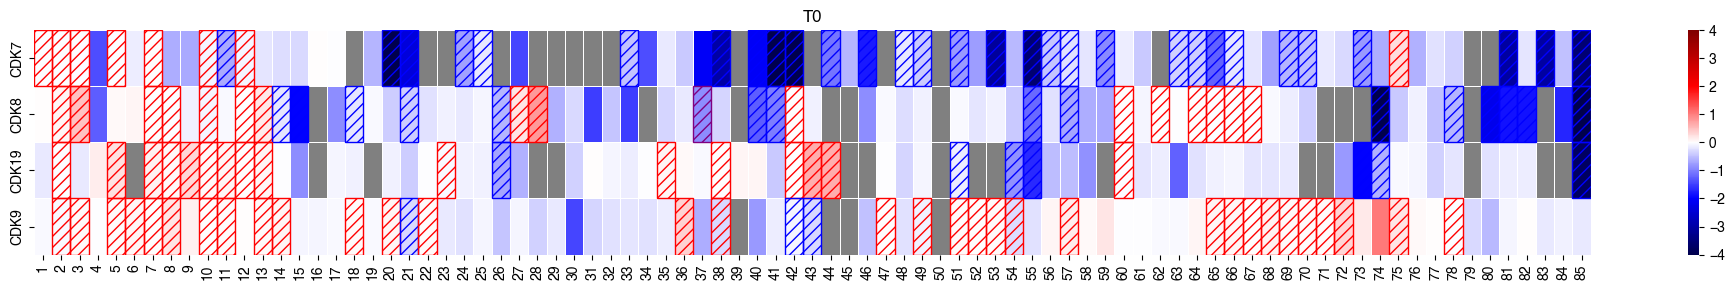

In [581]:
min_base_counts = 100
FDR_cutoff = 0.1
ABE_s1 = ABE_s1_plasmid[ABE_s1_plasmid['base_RAW']>=min_base_counts]
CBE_s1 = CBE_s1_plasmid[CBE_s1_plasmid['base_RAW']>=min_base_counts]

genes = ['CDK7', 'CDK8', 'CDK19', 'CDK9']
min_edit = 10

CBE_rg_dict, ABE_rg_dict = rg_dict_gen(SAV_ABE1, SAV_CBE1, genes, min_edit)

condition = 'T0'
plotting_a, fig = finger_plotv3(ABE_s1, CBE_s1, ABE_rg_dict, CBE_rg_dict, genes, FDR_cutoff, condition)

fig.savefig('../../figures/T0_subpool1.pdf', transparent=False)

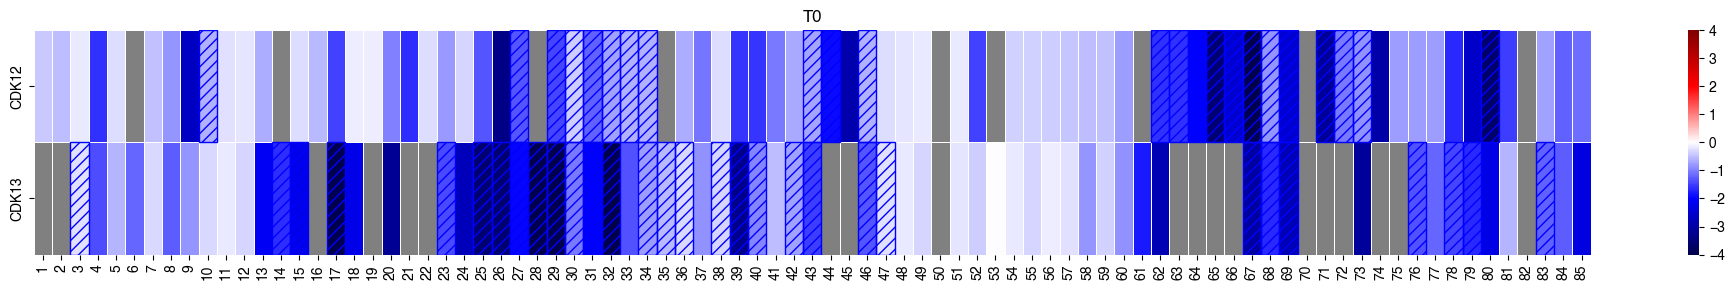

In [583]:
min_base_counts = 100
FDR_cutoff = 0.1
ABE_s2 = ABE_s2_plasmid[ABE_s2_plasmid['base_RAW']>=min_base_counts]
CBE_s2 = CBE_s2_plasmid[CBE_s2_plasmid['base_RAW']>=min_base_counts]

genes = ['CDK12', 'CDK13']
min_edit = 10

CBE_rg_dict, ABE_rg_dict = rg_dict_gen(SAV_ABE2, SAV_CBE2, genes, min_edit)

condition = 'T0'
plotting_a, fig = finger_plotv3(ABE_s2, CBE_s2, ABE_rg_dict, CBE_rg_dict, genes, FDR_cutoff, condition)
fig.savefig('../../figures/T0_subpool2.pdf', transparent=False)

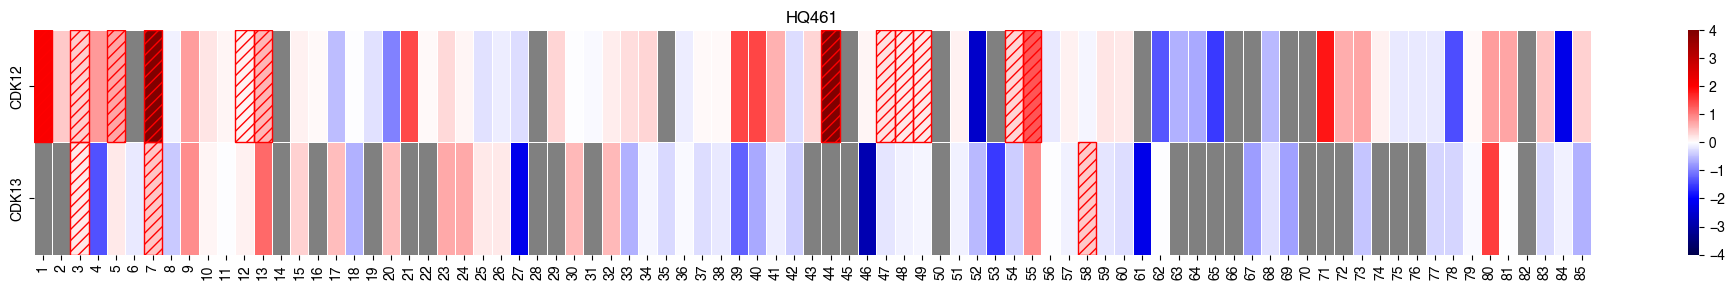

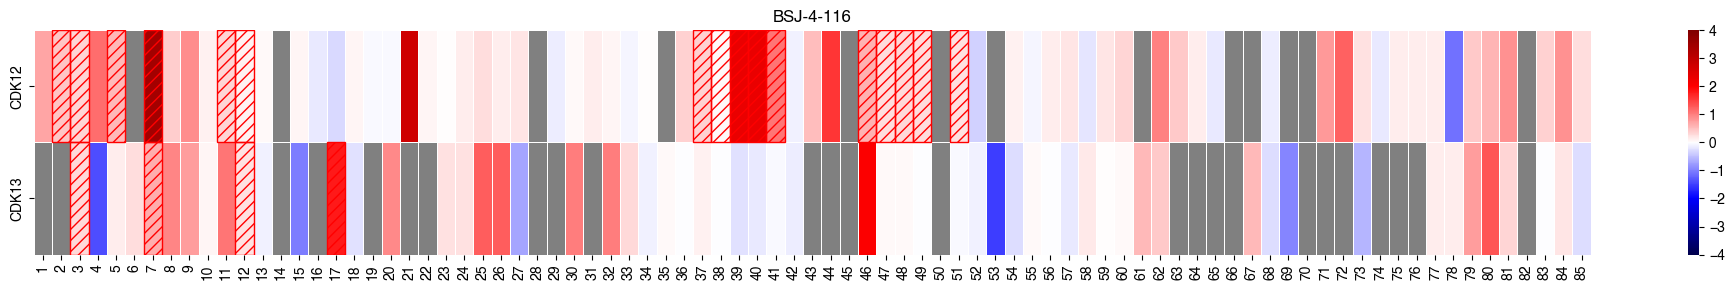

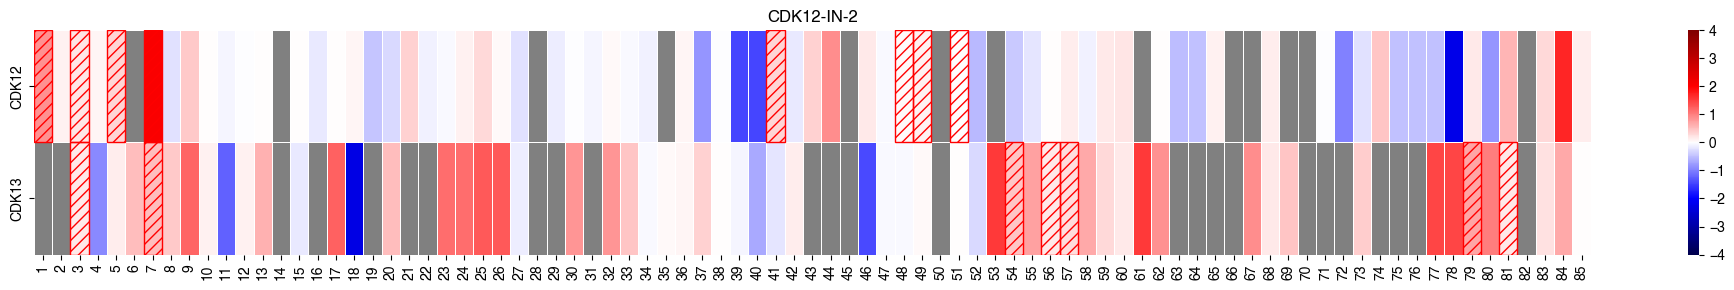

In [584]:
ABE_s2 = pd.read_csv('../../screening_data/03_LFC_FDR_tables/barcode_counts/DMSO_base/CDK12_13_ABE_barcode_DMSO_base.csv')
CBE_s2 = pd.read_csv('../../screening_data/03_LFC_FDR_tables/barcode_counts/DMSO_base/CDK12_13_CBE_barcode_DMSO_base.csv')

min_base_counts = 100
FDR_cutoff = 0.1
ABE_s2 = ABE_s2[ABE_s2['base_RAW']>=min_base_counts]
CBE_s2 = CBE_s2[CBE_s2['base_RAW']>=min_base_counts]

genes = ['CDK12', 'CDK13']
min_edit = 10

CBE_rg_dict, ABE_rg_dict = rg_dict_gen(SAV_ABE2, SAV_CBE2, genes, min_edit)

condition = 'HQ461'
plotting_b, fig = finger_plotv3(ABE_s2, CBE_s2, ABE_rg_dict, CBE_rg_dict, genes, FDR_cutoff, condition)
fig.savefig(f'../../figures/{condition}_KLIFS.pdf', transparent=False)


condition = 'BSJ-4-116'
plotting_c, fig = finger_plotv3(ABE_s2, CBE_s2, ABE_rg_dict, CBE_rg_dict, genes, FDR_cutoff, condition)
fig.savefig(f'../../figures/{condition}_KLIFS.pdf', transparent=False)

condition = 'CDK12-IN-2'
plotting_d, fig = finger_plotv3(ABE_s2, CBE_s2, ABE_rg_dict, CBE_rg_dict, genes, FDR_cutoff, condition)
fig.savefig(f'../../figures/{condition}_KLIFS.pdf', transparent=False)


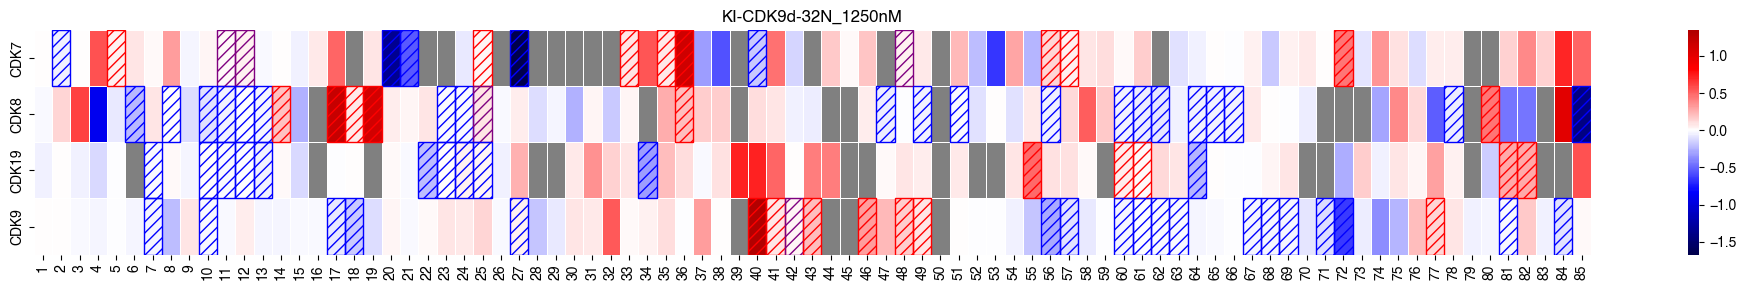

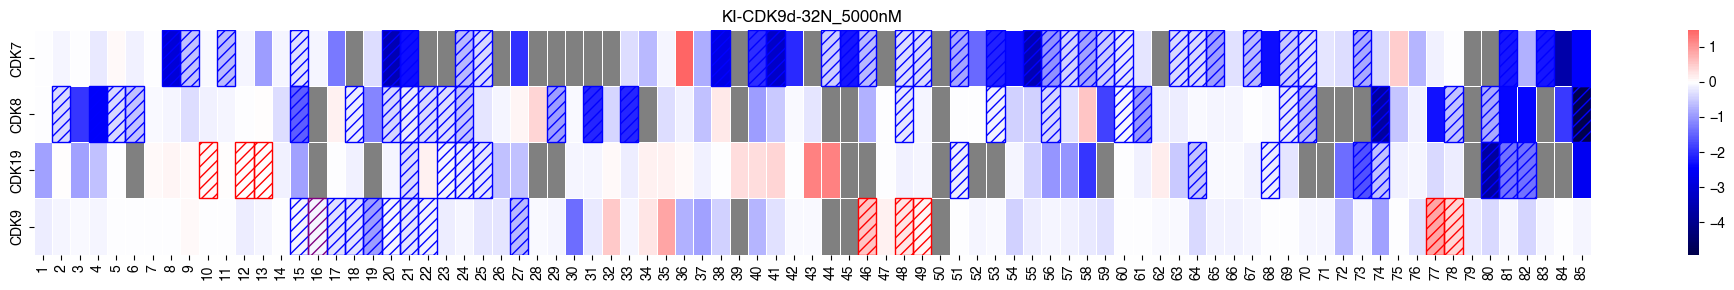

In [ ]:
ABE_s1 = pd.read_csv('../../screening_data/03_LFC_FDR_tables/barcode_counts/DMSO_base/ABE_subpool1_barcode_DMSO_base.csv')
CBE_s1 = pd.read_csv('../../screening_data/03_LFC_FDR_tables/barcode_counts/DMSO_base/CBE_subpool1_barcode_DMSO_base.csv')

min_base_counts = 100
FDR_cutoff = 0.1
min_edit = 10
ABE_s1 = ABE_s1[ABE_s1['base_RAW']>=min_base_counts]
CBE_s1 = CBE_s1[CBE_s1['base_RAW']>=min_base_counts]

genes = ['CDK7', 'CDK8', 'CDK19', 'CDK9']

CBE_rg_dict, ABE_rg_dict = rg_dict_gen(SAV_ABE1, SAV_CBE1, genes, min_edit)

condition = 'KI-CDK9d-32N_1250nM'
plotting_e, fig = finger_plotv3(ABE_s1, CBE_s1, ABE_rg_dict, CBE_rg_dict, genes, FDR_cutoff, condition)

condition = 'KI-CDK9d-32N_5000nM'
plotting_e, fig = finger_plotv3(ABE_s1, CBE_s1, ABE_rg_dict, CBE_rg_dict, genes, FDR_cutoff, condition)

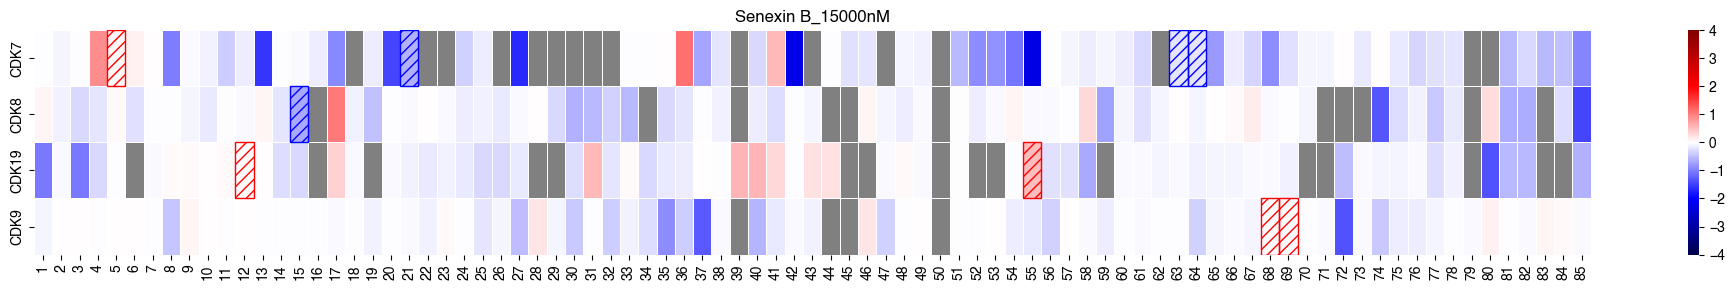

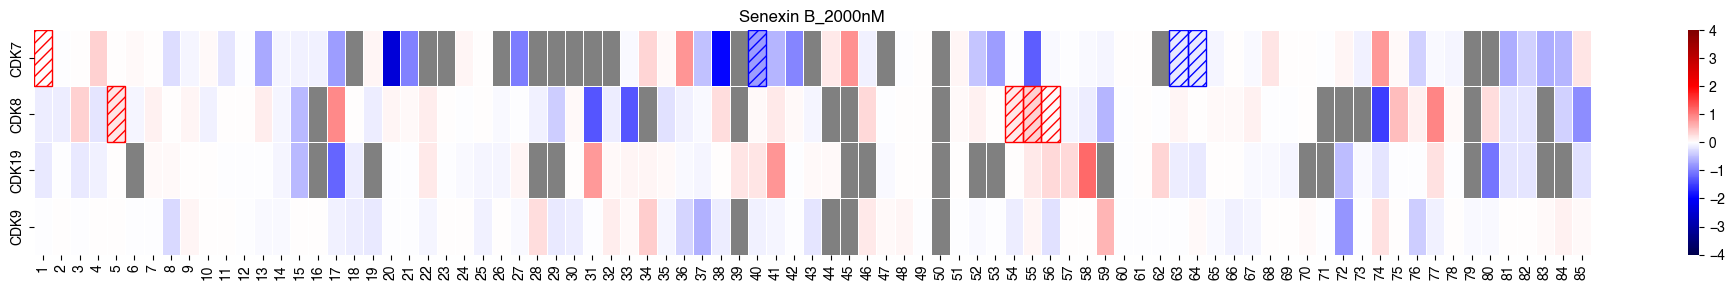

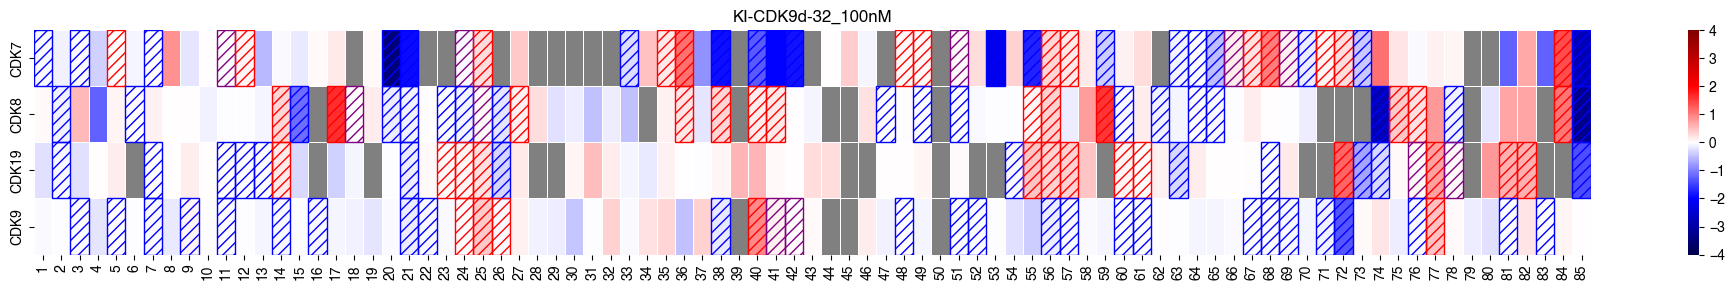

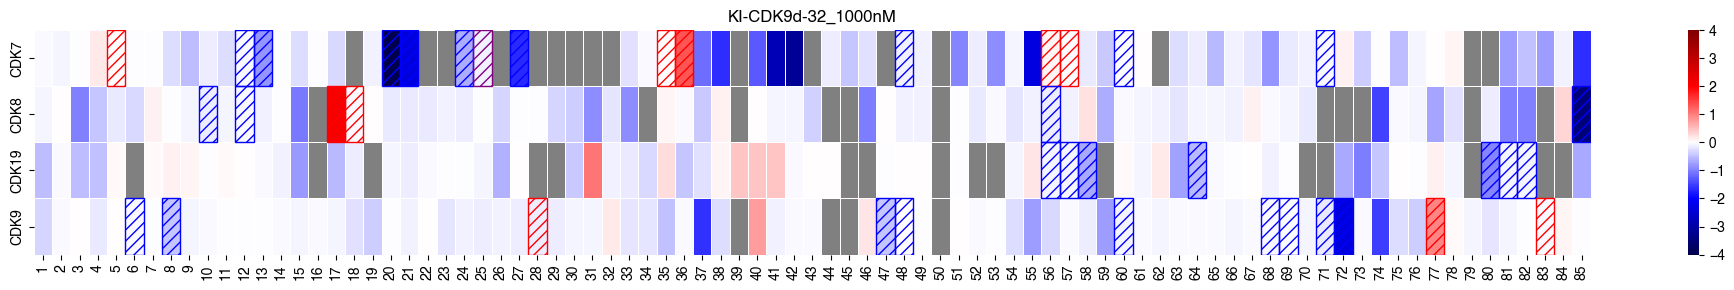

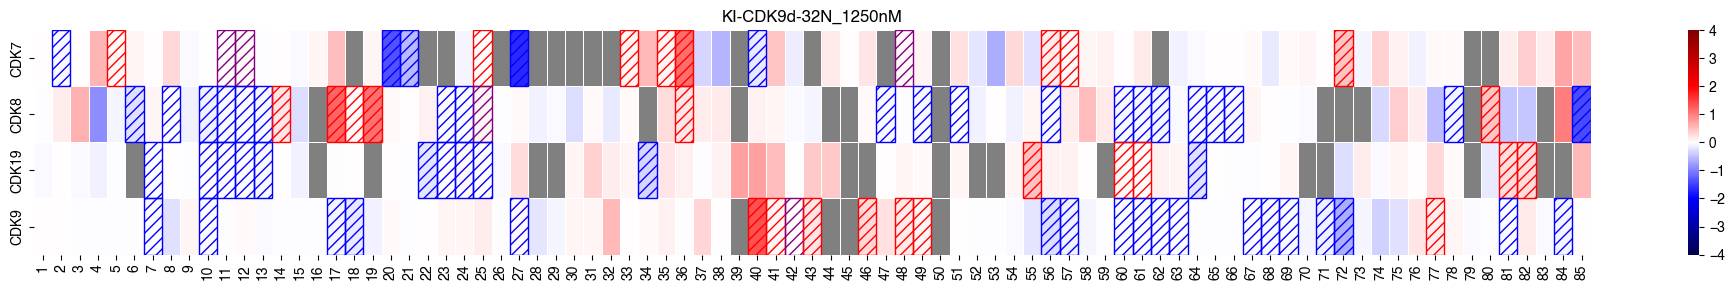

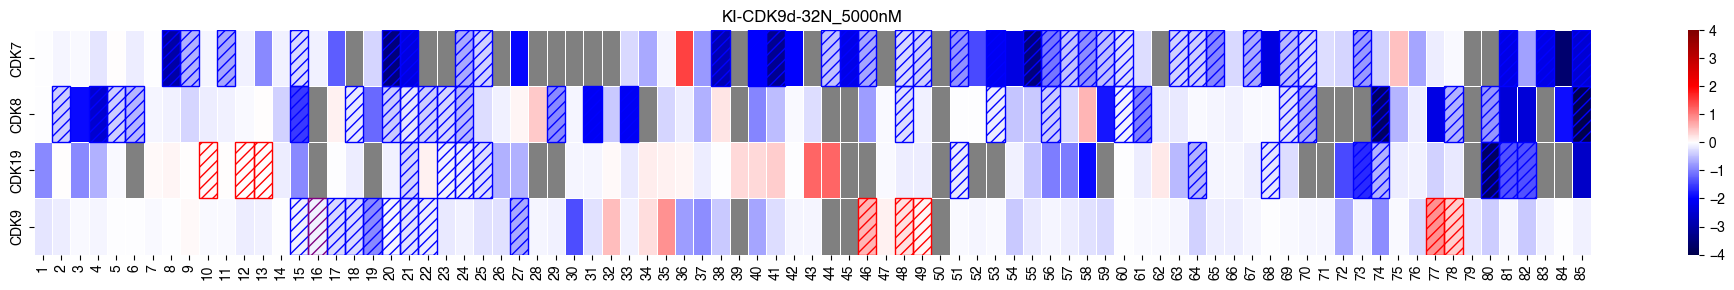

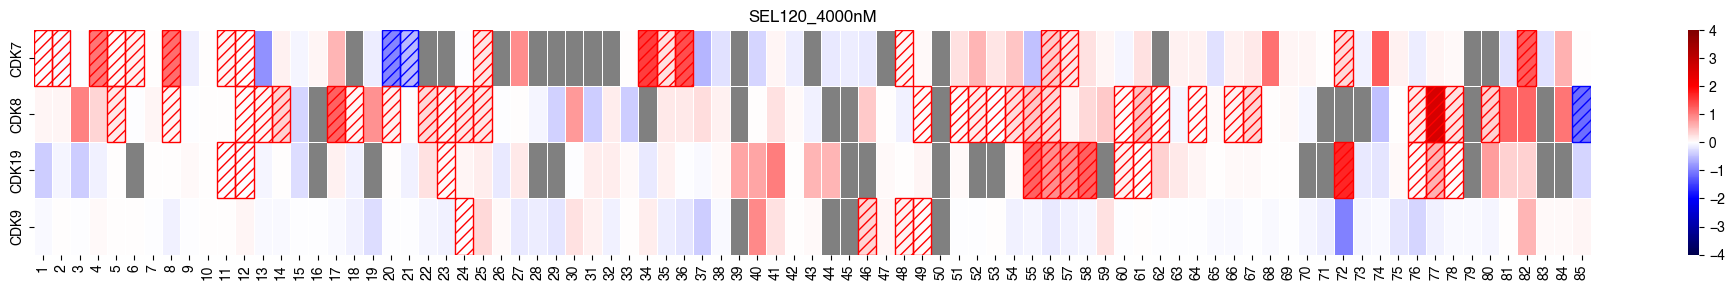

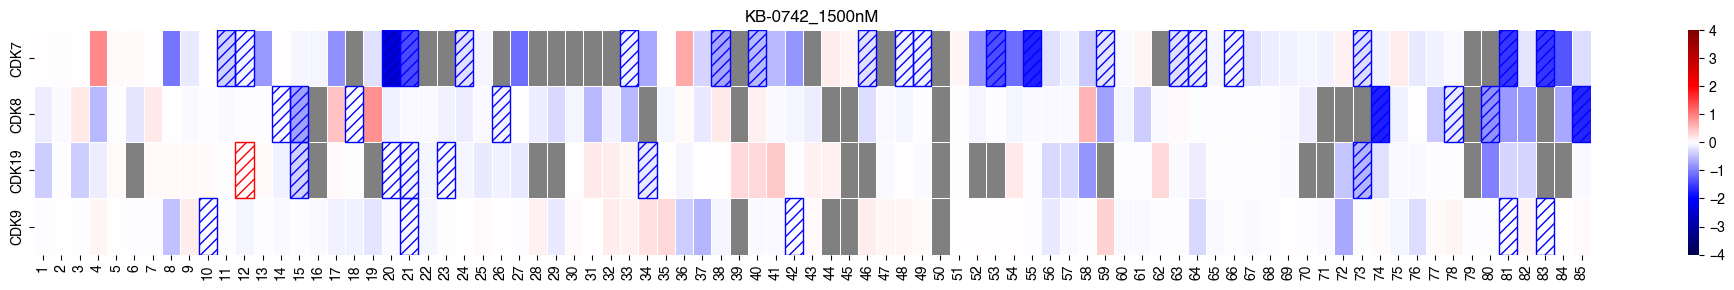

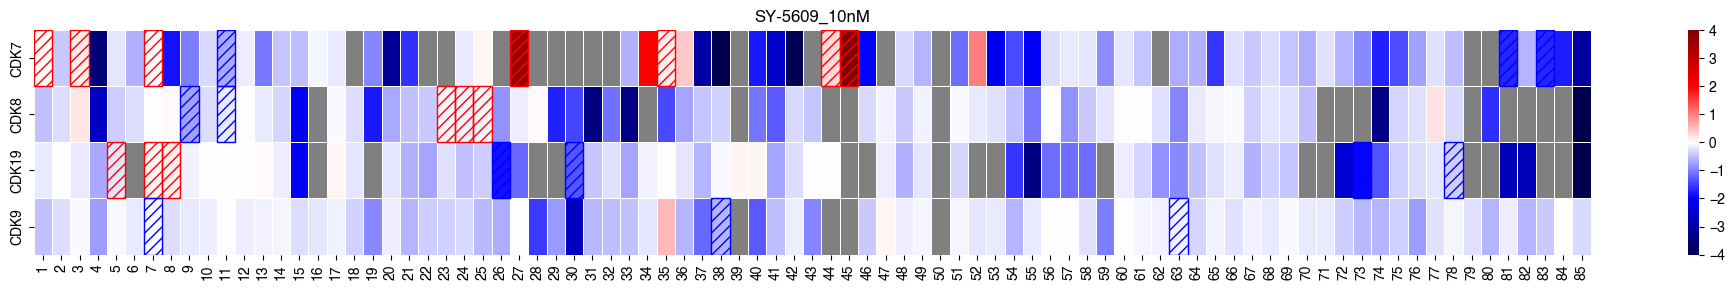

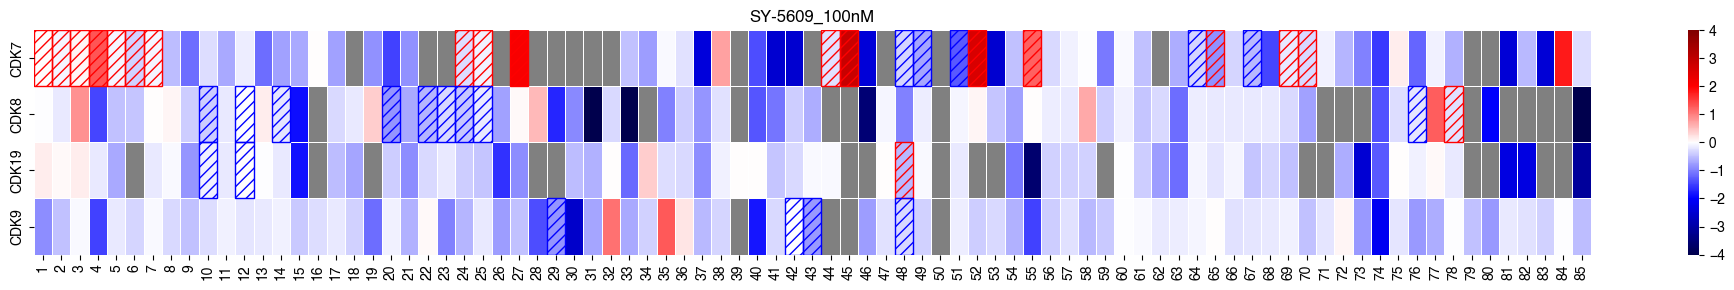

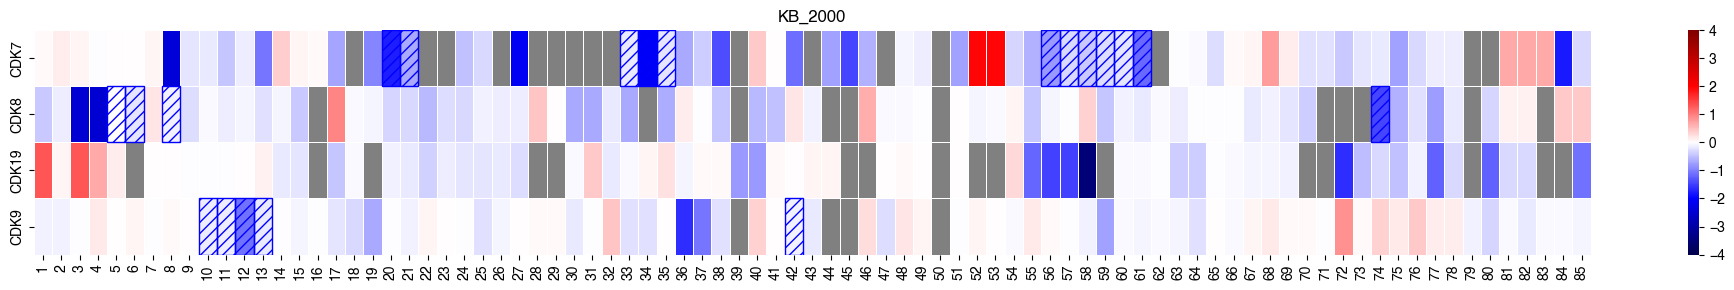

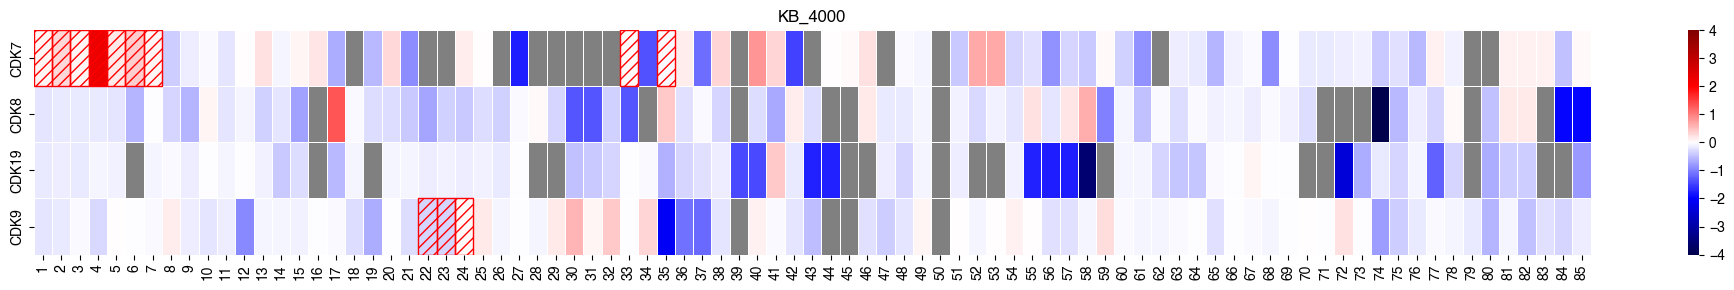

In [585]:
ABE_s1 = pd.read_csv('../../screening_data/03_LFC_FDR_tables/barcode_counts/DMSO_base/ABE_subpool1_barcode_DMSO_base.csv')
CBE_s1 = pd.read_csv('../../screening_data/03_LFC_FDR_tables/barcode_counts/DMSO_base/CBE_subpool1_barcode_DMSO_base.csv')

min_base_counts = 100
FDR_cutoff = 0.1
min_edit = 10
ABE_s1 = ABE_s1[ABE_s1['base_RAW']>=min_base_counts]
CBE_s1 = CBE_s1[CBE_s1['base_RAW']>=min_base_counts]

genes = ['CDK7', 'CDK8', 'CDK19', 'CDK9']

CBE_rg_dict, ABE_rg_dict = rg_dict_gen(SAV_ABE1, SAV_CBE1, genes, min_edit)


condition = 'Senexin B_15000nM'
plotting_a, fig = finger_plotv3(ABE_s1, CBE_s1, ABE_rg_dict, CBE_rg_dict, genes, FDR_cutoff, condition)
fig.savefig(f'../../figures/{condition}_KLIFS.pdf', transparent=False)

condition = 'Senexin B_2000nM'
plotting_b, fig = finger_plotv3(ABE_s1, CBE_s1, ABE_rg_dict, CBE_rg_dict, genes, FDR_cutoff, condition)
fig.savefig(f'../../figures/{condition}_KLIFS.pdf', transparent=False)

condition = 'KI-CDK9d-32_100nM'
plotting_c, fig = finger_plotv3(ABE_s1, CBE_s1, ABE_rg_dict, CBE_rg_dict, genes, FDR_cutoff, condition)
fig.savefig(f'../../figures/{condition}_KLIFS.pdf', transparent=False)

condition = 'KI-CDK9d-32_1000nM'
plotting_d, fig = finger_plotv3(ABE_s1, CBE_s1, ABE_rg_dict, CBE_rg_dict, genes, FDR_cutoff, condition)
fig.savefig(f'../../figures/{condition}_KLIFS.pdf', transparent=False)

condition = 'KI-CDK9d-32N_1250nM'
plotting_e, fig = finger_plotv3(ABE_s1, CBE_s1, ABE_rg_dict, CBE_rg_dict, genes, FDR_cutoff, condition)
fig.savefig(f'../../figures/{condition}_KLIFS.pdf', transparent=False)

condition = 'KI-CDK9d-32N_5000nM'
plotting_f, fig = finger_plotv3(ABE_s1, CBE_s1, ABE_rg_dict, CBE_rg_dict, genes, FDR_cutoff, condition)
fig.savefig(f'../../figures/{condition}_KLIFS.pdf', transparent=False)

condition = 'SEL120_4000nM'
plotting_g, fig = finger_plotv3(ABE_s1, CBE_s1, ABE_rg_dict, CBE_rg_dict, genes, FDR_cutoff, condition)
fig.savefig(f'../../figures/{condition}_KLIFS.pdf', transparent=False)

condition = 'KB-0742_1500nM'
plotting_gg, fig = finger_plotv3(ABE_s1, CBE_s1, ABE_rg_dict, CBE_rg_dict, genes, FDR_cutoff, condition)
fig.savefig(f'../../figures/{condition}_KLIFS.pdf', transparent=False)

#--------SY-------
ABE_sy = pd.read_csv('../../screening_data/03_LFC_FDR_tables/barcode_counts/DMSO_base/SY_5609_ABE_barcode_DMSO_base.csv')
CBE_sy = pd.read_csv('../../screening_data/03_LFC_FDR_tables/barcode_counts/DMSO_base/SY_5609_CBE_barcode_DMSO_base.csv')
ABE_sy = ABE_sy[ABE_sy['base_RAW']>=min_base_counts]
CBE_sy = CBE_sy[CBE_sy['base_RAW']>=min_base_counts]

condition = 'SY-5609_10nM'
plotting_h, fig = finger_plotv3(ABE_sy, CBE_sy, ABE_rg_dict, CBE_rg_dict, genes, FDR_cutoff, condition)
fig.savefig(f'../../figures/{condition}_KLIFS.pdf', transparent=False)

condition = 'SY-5609_100nM'
plotting_i, fig = finger_plotv3(ABE_sy, CBE_sy, ABE_rg_dict, CBE_rg_dict, genes, FDR_cutoff, condition)
fig.savefig(f'../../figures/{condition}_KLIFS.pdf', transparent=False)

#----compoun mutants------
#Note: hacky solution here; should limit to CBE-editable locations

#USING MATCHED COUNTS DATA HERE!!!
ABE_comp = pd.read_csv('../../screening_data/03_LFC_FDR_tables/proto_counts/DMSO_base/Compound_mutant_proto_DMSO_base.csv')
CBE_comp = ABE_comp
ABE_comp = ABE_comp[ABE_comp['base_RAW']>=min_base_counts]
CBE_comp = CBE_comp[CBE_comp['base_RAW']>=min_base_counts]

condition = 'KB_2000'
plotting_j, fig = finger_plotv3(ABE_comp, CBE_comp, ABE_rg_dict, CBE_rg_dict, genes, FDR_cutoff, condition)
fig.savefig(f'../../figures/{condition}_KLIFS_COMPOUND_PROTO_COUNTS.pdf', transparent=False)

condition = 'KB_4000'
plotting_k, fig = finger_plotv3(ABE_comp, CBE_comp, ABE_rg_dict, CBE_rg_dict, genes, FDR_cutoff, condition)
fig.savefig(f'../../figures/{condition}_KLIFS_COMPOUND_PROTO_COUNTS.pdf', transparent=False)



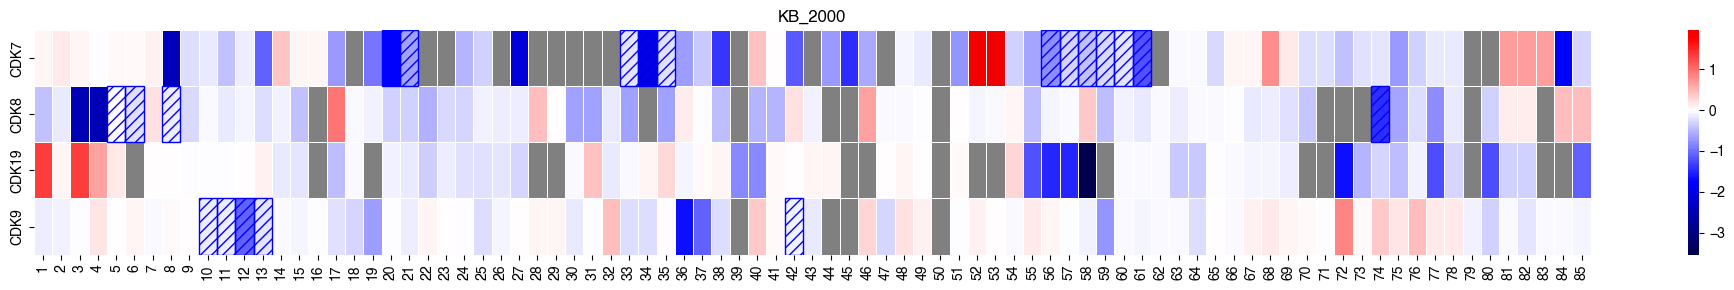

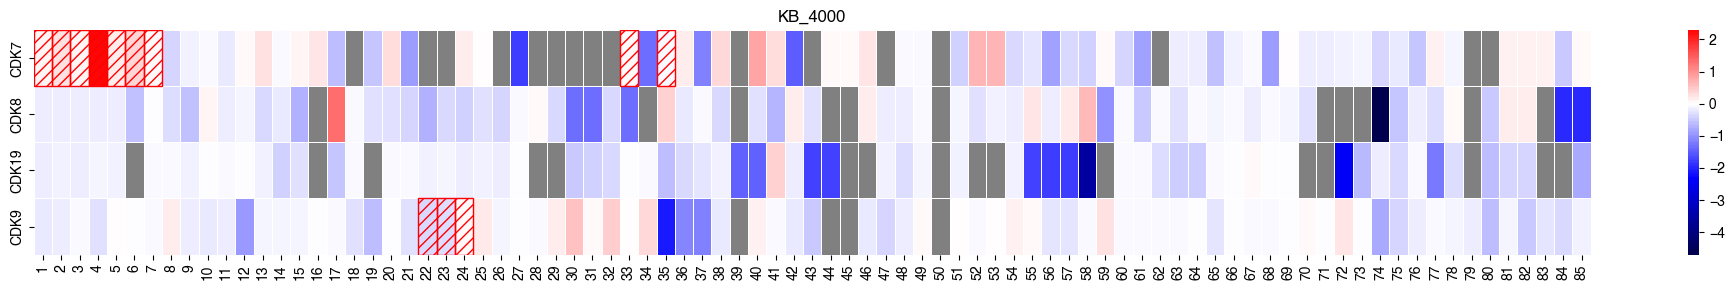

In [517]:
ABE_comp = pd.read_csv('../../screening_data/03_LFC_FDR_tables/proto_counts/DMSO_base/Compound_mutant_proto_DMSO_base.csv')
CBE_comp = ABE_comp
ABE_comp = ABE_comp[ABE_comp['base_RAW']>=min_base_counts]
CBE_comp = CBE_comp[CBE_comp['base_RAW']>=min_base_counts]

condition = 'KB_2000'
plotting_j = finger_plotv3(ABE_comp, CBE_comp, ABE_rg_dict, CBE_rg_dict, genes, FDR_cutoff, condition)

condition = 'KB_4000'
plotting_k = finger_plotv3(ABE_comp, CBE_comp, ABE_rg_dict, CBE_rg_dict, genes, FDR_cutoff, condition)

# Universal patterns

In [586]:
def top_hits(ABE_s2, CBE_s2, ABE_rg_dict, CBE_rg_dict, genes, FDR_cutoff, condition):

    #add coloring depending on if LFC >0 or LFC<0

    KLIFS2 = KLIFS.copy()

    #genes = ['CDK12', 'CDK13']

    for gene in genes:
        c = CBE_rg_dict[gene]
        a = ABE_rg_dict[gene]

        for i, val in KLIFS2.iterrows():
            nn = val[gene]
            try:
                subset_ABE = list(ABE_s2[ABE_s2['gRNA_id'].isin(a[i])][f'LFC_median_ABE_{condition}'])
                subset_CBE = list(CBE_s2[CBE_s2['gRNA_id'].isin(c[i])][f'LFC_median_CBE_{condition}'])

                #num_sig_ABE = len(ABE_s2[(ABE_s2['gRNA_id'].isin(a[i])) & (ABE_s2[f'FDR_ABE_{condition}']<FDR_cutoff)])
                #num_sig_CBE = len(CBE_s2[(CBE_s2['gRNA_id'].isin(c[i])) & (CBE_s2[f'FDR_CBE_{condition}']<FDR_cutoff)])

                num_sig_ABE_up = len(ABE_s2[(ABE_s2['gRNA_id'].isin(a[i])) & (ABE_s2[f'FDR_ABE_{condition}']<FDR_cutoff) & (ABE_s2[f'LFC_median_ABE_{condition}']>0)])
                num_sig_CBE_up = len(CBE_s2[(CBE_s2['gRNA_id'].isin(c[i])) & (CBE_s2[f'FDR_CBE_{condition}']<FDR_cutoff) & (CBE_s2[f'LFC_median_CBE_{condition}']>0)])
                num_sig_ABE_down = len(ABE_s2[(ABE_s2['gRNA_id'].isin(a[i])) & (ABE_s2[f'FDR_ABE_{condition}']<FDR_cutoff)& (ABE_s2[f'LFC_median_ABE_{condition}']<0)])
                num_sig_CBE_down = len(CBE_s2[(CBE_s2['gRNA_id'].isin(c[i])) & (CBE_s2[f'FDR_CBE_{condition}']<FDR_cutoff) & (CBE_s2[f'LFC_median_CBE_{condition}']<0)])
        
            except:
                subset_ABE = list(ABE_s2[ABE_s2['gRNA_id'].isin(a[i])][f'LFC_median_{condition}'])
                subset_CBE = list(CBE_s2[CBE_s2['gRNA_id'].isin(c[i])][f'LFC_median_{condition}'])

                num_sig_ABE_up = len(ABE_s2[(ABE_s2['gRNA_id'].isin(a[i])) & (ABE_s2[f'FDR_{condition}']<FDR_cutoff) & (ABE_s2[f'LFC_median_{condition}']>0)])
                num_sig_CBE_up = len(CBE_s2[(CBE_s2['gRNA_id'].isin(c[i])) & (CBE_s2[f'FDR_{condition}']<FDR_cutoff) & (CBE_s2[f'LFC_median_{condition}']>0)])
                num_sig_ABE_down = len(ABE_s2[(ABE_s2['gRNA_id'].isin(a[i])) & (ABE_s2[f'FDR_{condition}']<FDR_cutoff)& (ABE_s2[f'LFC_median_{condition}']<0)])
                num_sig_CBE_down = len(CBE_s2[(CBE_s2['gRNA_id'].isin(c[i])) & (CBE_s2[f'FDR_{condition}']<FDR_cutoff) & (CBE_s2[f'LFC_median_{condition}']<0)])


            total_sig_up = num_sig_ABE_up + num_sig_CBE_up
            total_sig_down = num_sig_ABE_down + num_sig_CBE_down
            comb1 = subset_ABE + subset_CBE

            KLIFS2.loc[KLIFS2[gene]==nn, f'{gene}_guides'] = len(comb1)
            KLIFS2.loc[KLIFS2[gene]==nn, f'{gene}_avg'] = np.average(comb1)
            KLIFS2.loc[KLIFS2[gene]==nn, f'{gene}_num_sig_up'] = total_sig_up
            KLIFS2.loc[KLIFS2[gene]==nn, f'{gene}_num_sig_down'] = total_sig_down
    
    #k2 = KLIFS2[['CDK12_guides', 'CDK12_avg', 'CDK13_guides', 'CDK13_avg']]

    return KLIFS2

In [590]:
ABE_s2 = pd.read_csv('../../screening_data/03_LFC_FDR_tables/barcode_counts/DMSO_base/CDK12_13_ABE_barcode_DMSO_base.csv')
CBE_s2 = pd.read_csv('../../screening_data/03_LFC_FDR_tables/barcode_counts/DMSO_base/CDK12_13_CBE_barcode_DMSO_base.csv')

min_base_counts = 100
FDR_cutoff = 0.1
min_edit = 10
ABE_s2 = ABE_s2[ABE_s2['base_RAW']>=min_base_counts]
CBE_s2 = CBE_s2[CBE_s2['base_RAW']>=min_base_counts]

genes = ['CDK12', 'CDK13']
min_edit = 10

CBE_rg_dict, ABE_rg_dict = rg_dict_gen(SAV_ABE2, SAV_CBE2, genes, min_edit)

condition = 'HQ461'

conditions = ['HQ461', 'BSJ-4-116', 'CDK12-IN-2']

tot_up = np.zeros(85)
tot_down = np.zeros(85)

up_holder = []
down_holder = []


for condition in conditions:

    KLIFS_hq = top_hits(ABE_s2, CBE_s2, ABE_rg_dict, CBE_rg_dict, genes, FDR_cutoff, condition)

    up_hq = KLIFS_hq[['CDK12_num_sig_up',  'CDK13_num_sig_up']]
    down_hq = KLIFS_hq[['CDK12_num_sig_down', 'CDK13_num_sig_down']]

    tot_up += up_hq.sum(axis=1)
    tot_down += down_hq.sum(axis=1)

    up_holder.append(up_hq)
    down_holder.append(down_hq)
    

comb_up1 = sum(up_holder)
comb_down1 = sum(down_holder)



In [591]:
ABE_s1 = pd.read_csv('../../screening_data/03_LFC_FDR_tables/barcode_counts/DMSO_base/ABE_subpool1_barcode_DMSO_base.csv')
CBE_s1 = pd.read_csv('../../screening_data/03_LFC_FDR_tables/barcode_counts/DMSO_base/CBE_subpool1_barcode_DMSO_base.csv')

min_base_counts = 100
FDR_cutoff = 0.1
min_edit = 10
ABE_s1 = ABE_s1[ABE_s1['base_RAW']>=min_base_counts]
CBE_s1 = CBE_s1[CBE_s1['base_RAW']>=min_base_counts]

genes = ['CDK7', 'CDK8', 'CDK19', 'CDK9']

CBE_rg_dict, ABE_rg_dict = rg_dict_gen(SAV_ABE1, SAV_CBE1, genes, min_edit)


conditions = ['Senexin B_15000nM', 'Senexin B_2000nM', 'KI-CDK9d-32_100nM', 'KI-CDK9d-32_1000nM', 'KI-CDK9d-32N_1250nM', 'KI-CDK9d-32N_5000nM', 'SEL120_4000nM', 'KB-0742_1500nM']


tot_up2 = np.zeros(85)
tot_down2 = np.zeros(85)

up_holder = []
down_holder = []

for condition in conditions:

    KLIFS_hq = top_hits(ABE_s1, CBE_s1, ABE_rg_dict, CBE_rg_dict, genes, FDR_cutoff, condition)

    up_hq = KLIFS_hq[['CDK7_num_sig_up',  'CDK8_num_sig_up', 'CDK9_num_sig_up', 'CDK19_num_sig_up']]
    down_hq = KLIFS_hq[['CDK7_num_sig_down',  'CDK8_num_sig_down', 'CDK9_num_sig_down', 'CDK19_num_sig_down']]

    tot_up2 += up_hq.sum(axis=1)
    tot_down2 += down_hq.sum(axis=1)

    up_holder.append(up_hq)
    down_holder.append(down_hq)
    

comb_up2 = sum(up_holder)
comb_down2 = sum(down_holder)

In [592]:
#--------SY-------
ABE_sy = pd.read_csv('../../screening_data/03_LFC_FDR_tables/barcode_counts/DMSO_base/SY_5609_ABE_barcode_DMSO_base.csv')
CBE_sy = pd.read_csv('../../screening_data/03_LFC_FDR_tables/barcode_counts/DMSO_base/SY_5609_CBE_barcode_DMSO_base.csv')
ABE_sy = ABE_sy[ABE_sy['base_RAW']>=min_base_counts]
CBE_sy = CBE_sy[CBE_sy['base_RAW']>=min_base_counts]


CBE_rg_dict, ABE_rg_dict = rg_dict_gen(SAV_ABE1, SAV_CBE1, genes, min_edit)


conditions = ['SY-5609_100nM', 'SY-5609_10nM']

tot_up3 = np.zeros(85)
tot_down3 = np.zeros(85)

up_holder = []
down_holder = []

for condition in conditions:

    KLIFS_hq = top_hits(ABE_sy, CBE_sy, ABE_rg_dict, CBE_rg_dict, genes, FDR_cutoff, condition)

    up_hq = KLIFS_hq[['CDK7_num_sig_up',  'CDK8_num_sig_up', 'CDK9_num_sig_up', 'CDK19_num_sig_up']]
    down_hq = KLIFS_hq[['CDK7_num_sig_down',  'CDK8_num_sig_down', 'CDK9_num_sig_down', 'CDK19_num_sig_down']]

    tot_up3 += up_hq.sum(axis=1)
    tot_down3 += down_hq.sum(axis=1)

    up_holder.append(up_hq)
    down_holder.append(down_hq)
    

comb_up3 = sum(up_holder)
comb_down3 = sum(down_holder)



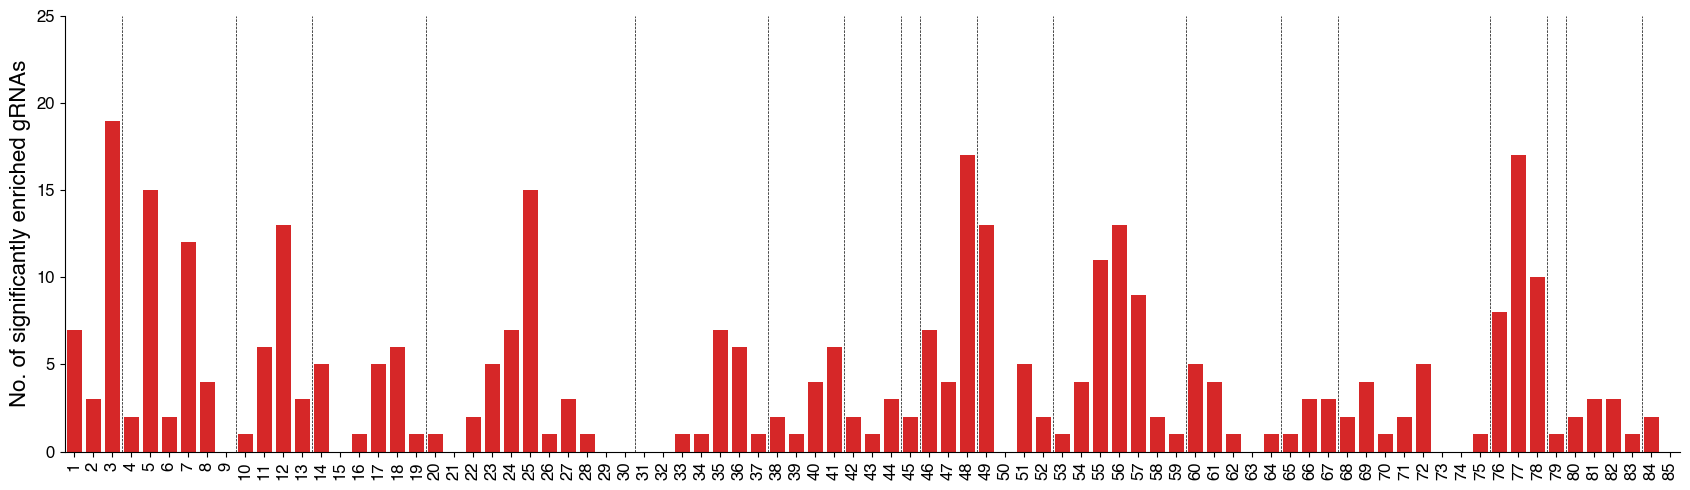

In [598]:
fig, ax = plt.subplots(figsize=(17,5))

ax.bar(range(1,86), tot_up + tot_up2 + tot_up3, color='tab:red')
ax.set_xlim(0.5,85.5)
ax.set_ylabel('No. of significantly enriched gRNAs', fontsize=16)

ax.spines[['right', 'top']].set_visible(False)
ax.tick_params(axis='both', which='major', labelsize=12)
ax.set_xticks(list(range(1,86)))
ax.set_xticklabels(list(range(1,86)), rotation=90)
ax.set_ylim(0,25)

locs = np.asarray([3.5, 9.5, 13.5, 19.5, 30.5, 37.5, 41.5, 44.5, 45.5, 48.5, 52.5, 59.5, 64.5, 67.5, 75.5, 78.5, 79.5, 83.5])
for i in locs:
    ax.axvline(i, linestyle='dashed', color='black', linewidth=0.5)

fig.tight_layout()

#fig.savefig('../../figures/sig_up_KLIFS_FDR_0.1.pdf', transparent=True)

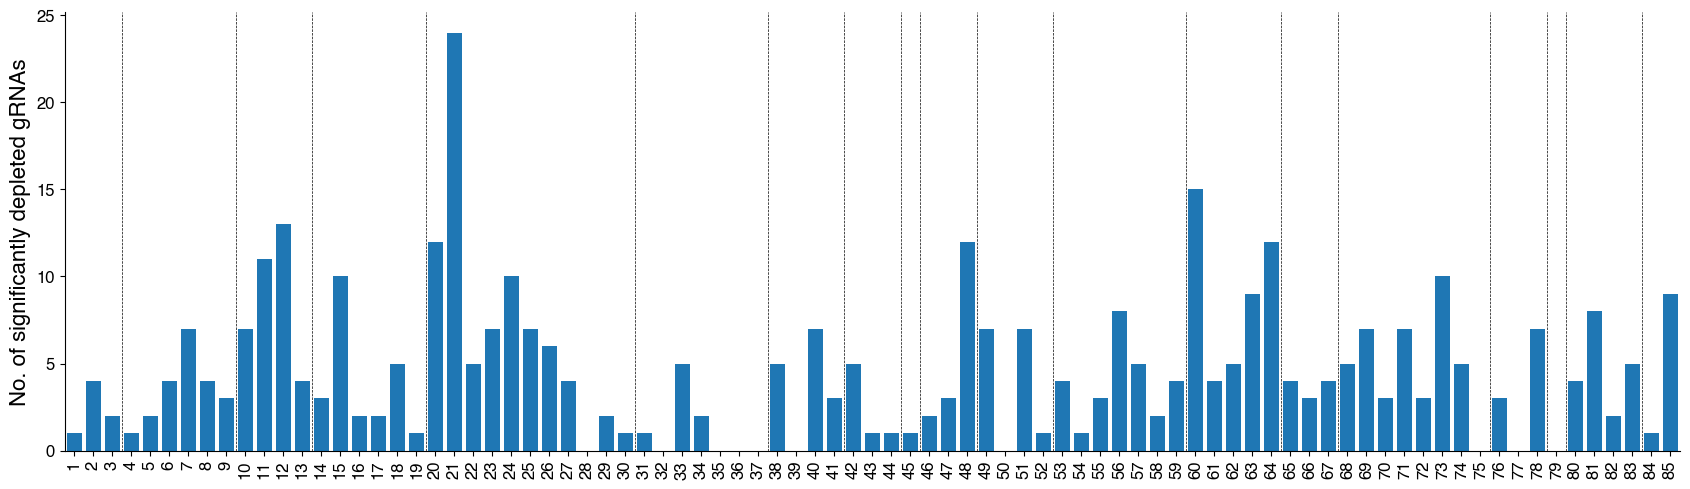

In [597]:
fig, ax = plt.subplots(figsize=(17,5))

ax.bar(range(1,86), tot_down + tot_down2 + tot_down3, color='tab:blue')
ax.set_xlim(0.5,85.5)
ax.set_ylabel('No. of significantly depleted gRNAs', fontsize=16)

ax.spines[['right', 'top']].set_visible(False)
ax.tick_params(axis='both', which='major', labelsize=12)
ax.set_xticks(list(range(1,86)))
ax.set_xticklabels(list(range(1,86)), rotation=90)
#ax.set_ylim(0,65)

locs = np.asarray([3.5, 9.5, 13.5, 19.5, 30.5, 37.5, 41.5, 44.5, 45.5, 48.5, 52.5, 59.5, 64.5, 67.5, 75.5, 78.5, 79.5, 83.5])
for i in locs:
    ax.axvline(i, linestyle='dashed', color='black', linewidth=0.5)

fig.tight_layout()
#fig.savefig('../../figures/sig_down_KLIFS.pdf', transparent=True)

In [605]:
sub1 = comb_up2 + comb_up3

sub2 = comb_up1.rename(columns = {'CDK12_num_sig_up':'CDK12', 'CDK13_num_sig_up':'CDK13'})
sub1 = sub1.rename(columns = {'CDK7_num_sig_up':'CDK7', 'CDK8_num_sig_up':'CDK8', 'CDK9_num_sig_up':'CDK9', 'CDK19_num_sig_up':'CDK19'})

combined1 = pd.concat((sub1, sub2), axis=1)
combined1['KLIFS Index'] = list(range(1,86))
melted = pd.melt(combined1, id_vars='KLIFS Index')

melted

,KLIFS Index,variable,value
0,1,CDK7,5.0
1,2,CDK7,2.0
2,3,CDK7,7.0
3,4,CDK7,2.0
4,5,CDK7,7.0
...,...,...,...
505,81,CDK13,1.0
506,82,CDK13,0.0
507,83,CDK13,0.0
508,84,CDK13,0.0


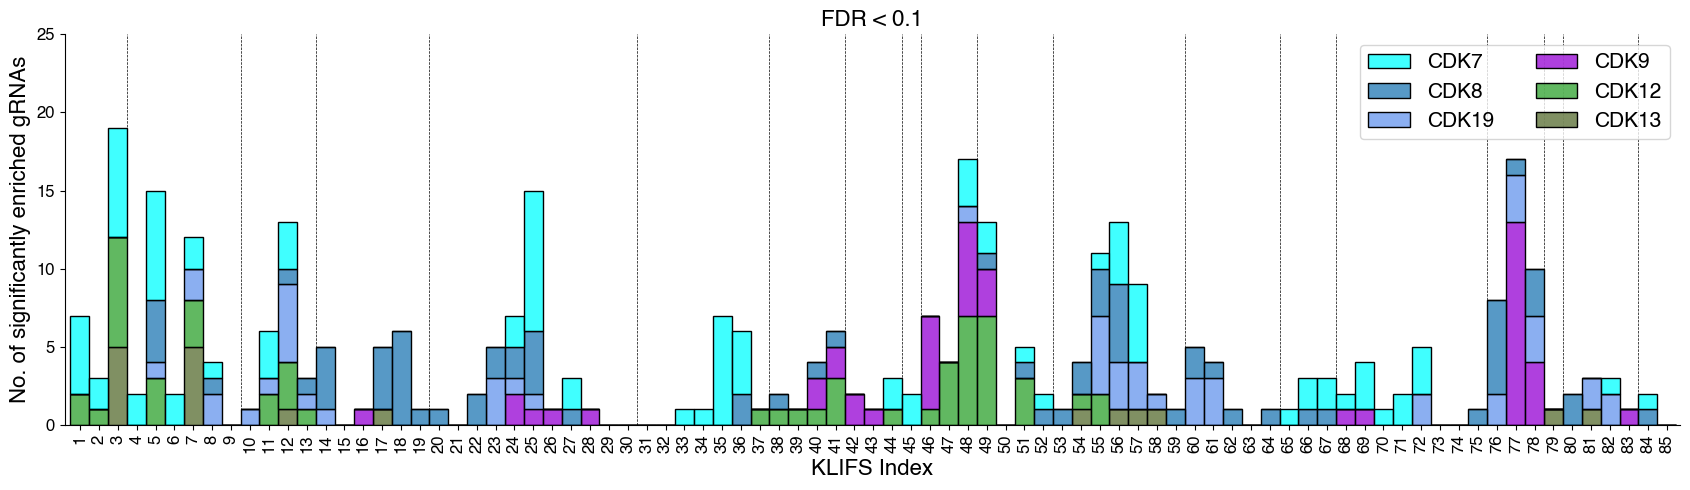

In [ ]:
fig, ax = plt.subplots(figsize=(17,5))

color_dict = {'CDK7':'cyan', 
              'CDK8':'tab:blue', 
              'CDK19':'cornflowerblue', 
              'CDK9':'darkviolet', 
              'CDK12':'tab:green', 
              'CDK13':'darkolivegreen'}

palette = list(color_dict.values())

hue_order = list(color_dict.keys())

sns.histplot(data = melted, bins = np.linspace(1,85,85), x = 'KLIFS Index',  ax=ax, weights='value', hue='variable', multiple='stack',discrete=True, legend=True, palette=palette, hue_order=hue_order)
#sns.stripplot(data = combined_klifs_edit, x = 'KLIFS Index', y='No. of gRNAs Targeting Codon', hue='Gene')


sns.move_legend(ax, "upper right", fontsize=15, ncols=2, title='')

ax.set_xlim(0.2,85.7)
ax.set_ylabel('No. of significantly enriched gRNAs', fontsize=16)
#ax.legend(fontsize=18)
ax.spines[['right', 'top']].set_visible(False)
ax.tick_params(axis='both', which='major', labelsize=12)
ax.set_xticks(list(range(1,86)))
ax.set_xticklabels(list(range(1,86)), rotation=90)
ax.set_xlabel('KLIFS Index', fontsize=16)
#ax.set_title(f'Observed Resistance Mutations (OncoKB R1 & R2) n= {sum(melt_plot["count"])}', fontsize=16)
#ax.set_ylim(0,65)
ax.set_title(f'FDR < {FDR_cutoff}', fontsize=16)

ax.set_ylim(0,25)

locs = np.asarray([3.5, 9.5, 13.5, 19.5, 30.5, 37.5, 41.5, 44.5, 45.5, 48.5, 52.5, 59.5, 64.5, 67.5, 75.5, 78.5, 79.5, 83.5])
for i in locs:
    ax.axvline(i, linestyle='dashed', color='black', linewidth=0.5)
    
#sns.move_legend(ax, "center right")

fig.tight_layout()
#fig.savefig(f'../../figures/sig_up_FDR_{FDR_cutoff}_by_gene.pdf', transparent=True)

In [607]:
sub1 = comb_down2 + comb_down3

sub2 = comb_down1.rename(columns = {'CDK12_num_sig_down':'CDK12', 'CDK13_num_sig_down':'CDK13'})
sub1 = sub1.rename(columns = {'CDK7_num_sig_down':'CDK7', 'CDK8_num_sig_down':'CDK8', 'CDK9_num_sig_down':'CDK9', 'CDK19_num_sig_down':'CDK19'})

combined1 = pd.concat((sub1, sub2), axis=1)
combined1['KLIFS Index'] = list(range(1,86))
melted = pd.melt(combined1, id_vars='KLIFS Index')

melted

,KLIFS Index,variable,value
0,1,CDK7,1.0
1,2,CDK7,1.0
2,3,CDK7,1.0
3,4,CDK7,0.0
4,5,CDK7,0.0
...,...,...,...
505,81,CDK13,0.0
506,82,CDK13,0.0
507,83,CDK13,0.0
508,84,CDK13,0.0


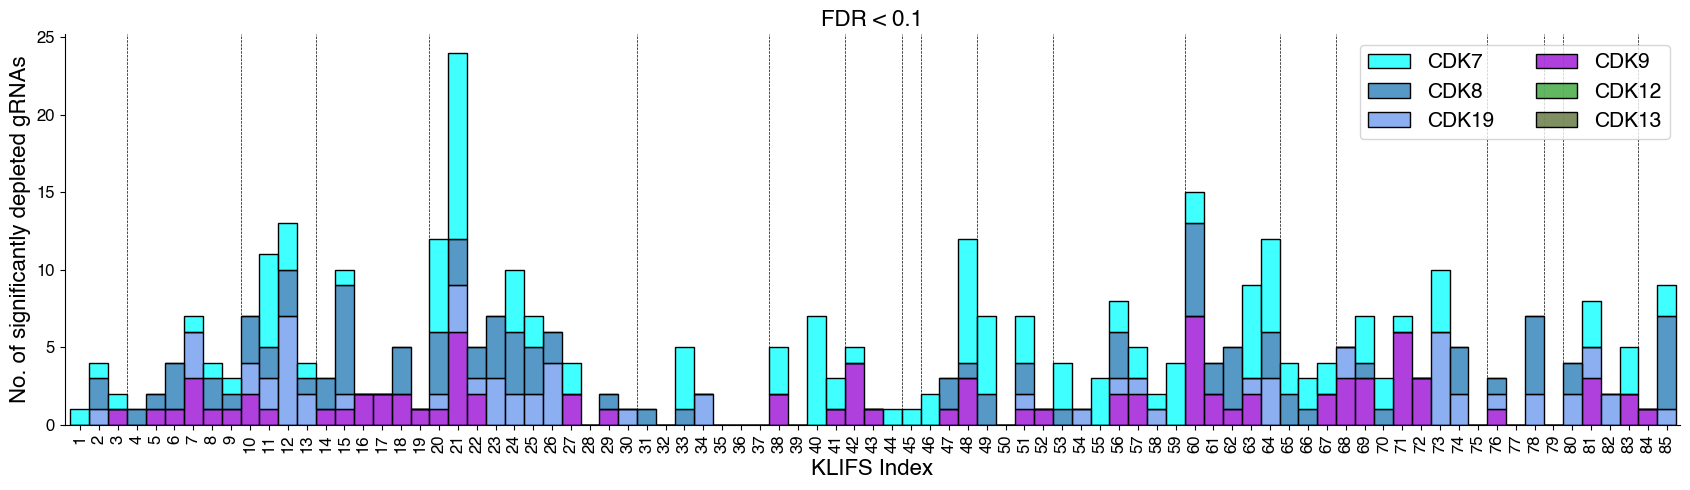

In [ ]:
fig, ax = plt.subplots(figsize=(17,5))

color_dict = {'CDK7':'cyan', 
              'CDK8':'tab:blue', 
              'CDK19':'cornflowerblue', 
              'CDK9':'darkviolet', 
              'CDK12':'tab:green', 
              'CDK13':'darkolivegreen'}

palette = list(color_dict.values())

hue_order = list(color_dict.keys())

sns.histplot(data = melted, bins = np.linspace(1,85,85), x = 'KLIFS Index',  ax=ax, weights='value', hue='variable', multiple='stack',discrete=True, legend=True, palette=palette, hue_order=hue_order)
#sns.stripplot(data = combined_klifs_edit, x = 'KLIFS Index', y='No. of gRNAs Targeting Codon', hue='Gene')


sns.move_legend(ax, "upper right", fontsize=15, ncols=2, title='')

ax.set_xlim(0.2,85.7)
ax.set_ylabel('No. of significantly depleted gRNAs', fontsize=16)
#ax.legend(fontsize=18)
ax.spines[['right', 'top']].set_visible(False)
ax.tick_params(axis='both', which='major', labelsize=12)
ax.set_xticks(list(range(1,86)))
ax.set_xticklabels(list(range(1,86)), rotation=90)
ax.set_xlabel('KLIFS Index', fontsize=16)
#ax.set_ylim(0,65)
ax.set_title(f'FDR < {FDR_cutoff}', fontsize=16)

locs = np.asarray([3.5, 9.5, 13.5, 19.5, 30.5, 37.5, 41.5, 44.5, 45.5, 48.5, 52.5, 59.5, 64.5, 67.5, 75.5, 78.5, 79.5, 83.5])
for i in locs:
    ax.axvline(i, linestyle='dashed', color='black', linewidth=0.5)

#sns.move_legend(ax, "center right")

fig.tight_layout()
#fig.savefig(f'../../figures/sig_down_FDR_{FDR_cutoff}_by_gene.pdf', transparent=True)

In [611]:
#and for T0 as well!
ABE_s1_plasmid = pd.read_csv('../../screening_data/03_LFC_FDR_tables/barcode_counts/Plasmid_base/ABE_subpool1_barcode_Plasmid_base.csv')
CBE_s1_plasmid = pd.read_csv('../../screening_data/03_LFC_FDR_tables/barcode_counts/Plasmid_base/CBE_subpool1_barcode_Plasmid_base.csv')

ABE_s2_plasmid = pd.read_csv('../../screening_data/03_LFC_FDR_tables/barcode_counts/Plasmid_base/CDK12_13_ABE_barcode_Plasmid_base.csv')
CBE_s2_plasmid = pd.read_csv('../../screening_data/03_LFC_FDR_tables/barcode_counts/Plasmid_base/CDK12_13_CBE_barcode_Plasmid_base.csv')


min_base_counts = 100
FDR_cutoff = 0.1
ABE_s1_plasmid = ABE_s1_plasmid[ABE_s1_plasmid['base_RAW']>=min_base_counts]
CBE_s1_plasmid = CBE_s1_plasmid[CBE_s1_plasmid['base_RAW']>=min_base_counts]

genes = ['CDK7', 'CDK8', 'CDK19', 'CDK9']
min_edit = 10

CBE_rg_dict, ABE_rg_dict = rg_dict_gen(SAV_ABE1, SAV_CBE1, genes, min_edit)

condition = 'T0'
KLIFS_hq = top_hits(ABE_s1_plasmid, CBE_s1_plasmid, ABE_rg_dict, CBE_rg_dict, genes, FDR_cutoff, condition)

up_hq1 = KLIFS_hq[['CDK7_num_sig_up',  'CDK8_num_sig_up', 'CDK9_num_sig_up', 'CDK19_num_sig_up']]
down_hq1 = KLIFS_hq[['CDK7_num_sig_down',  'CDK8_num_sig_down', 'CDK9_num_sig_down', 'CDK19_num_sig_down']]

tot_up_s1 = up_hq1.sum(axis=1)
tot_down_s1 = down_hq1.sum(axis=1)

#-------and subpool1

min_base_counts = 100
FDR_cutoff = 0.1
ABE_s2_plasmid = ABE_s2_plasmid[ABE_s2_plasmid['base_RAW']>=min_base_counts]
CBE_s2_plasmid = CBE_s2_plasmid[CBE_s2_plasmid['base_RAW']>=min_base_counts]

genes = ['CDK12', 'CDK13']
min_edit = 10

CBE_rg_dict, ABE_rg_dict = rg_dict_gen(SAV_ABE2, SAV_CBE2, genes, min_edit)

condition = 'T0'

KLIFS_hq = top_hits(ABE_s2_plasmid, CBE_s2_plasmid, ABE_rg_dict, CBE_rg_dict, genes, FDR_cutoff, condition)

up_hq2 = KLIFS_hq[['CDK12_num_sig_up',  'CDK13_num_sig_up']]
down_hq2 = KLIFS_hq[['CDK12_num_sig_down', 'CDK13_num_sig_down']]

tot_up_s2 = up_hq2.sum(axis=1)
tot_down_s2 = down_hq2.sum(axis=1)


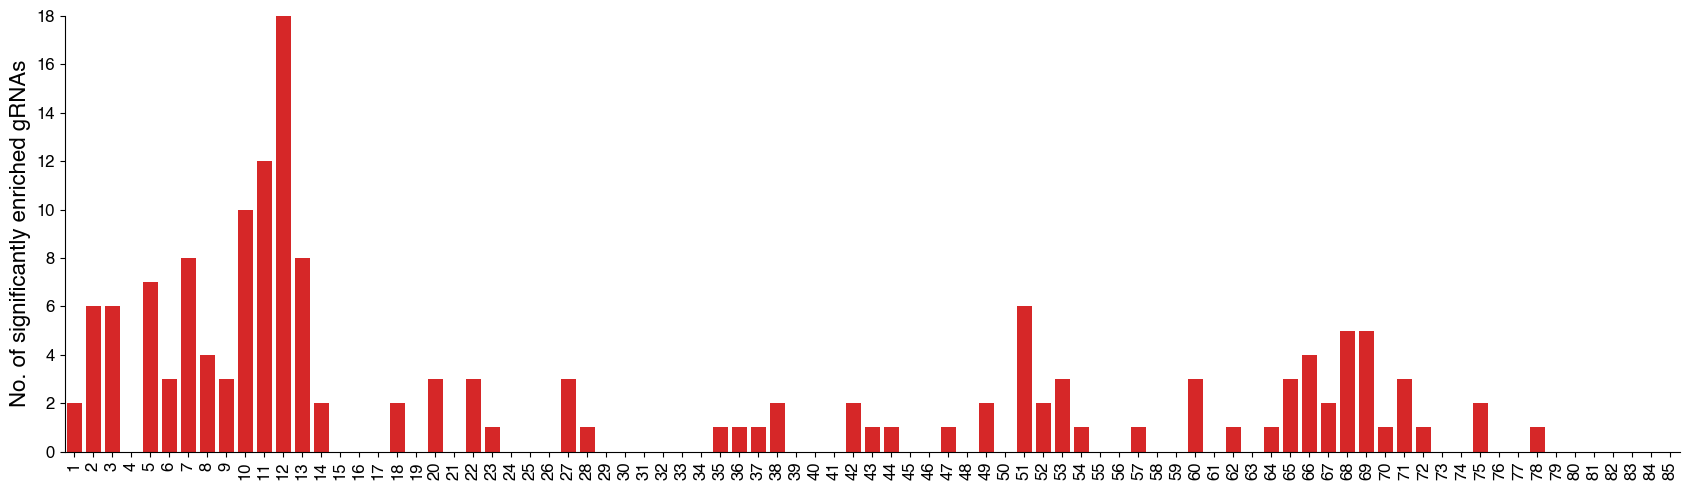

In [535]:
fig, ax = plt.subplots(figsize=(17,5))

ax.bar(range(1,86), tot_up_s2 + tot_up_s1, color='tab:red')
ax.set_xlim(0.5,85.5)
ax.set_ylabel('No. of significantly enriched gRNAs', fontsize=16)

ax.spines[['right', 'top']].set_visible(False)
ax.tick_params(axis='both', which='major', labelsize=12)
ax.set_xticks(list(range(1,86)))
ax.set_xticklabels(list(range(1,86)), rotation=90)
ax.set_ylim(0,18)
fig.tight_layout()
#fig.savefig('../../figures/sig_up_KLIFS_T0.pdf', transparent=True)

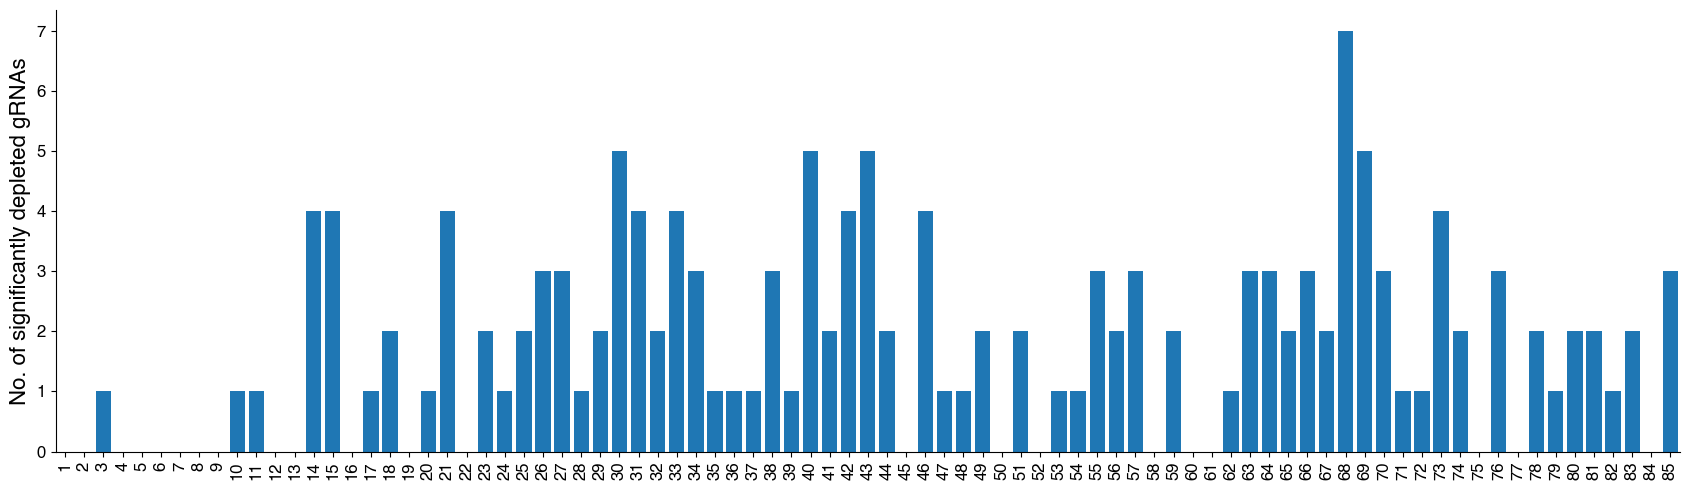

In [536]:
fig, ax = plt.subplots(figsize=(17,5))

ax.bar(range(1,86), tot_down_s1 +tot_down_s2 , color='tab:blue')
ax.set_xlim(0.5,85.5)
ax.set_ylabel('No. of significantly depleted gRNAs', fontsize=16)

ax.spines[['right', 'top']].set_visible(False)
ax.tick_params(axis='both', which='major', labelsize=12)
ax.set_xticks(list(range(1,86)))
ax.set_xticklabels(list(range(1,86)), rotation=90)

fig.tight_layout()
#fig.savefig('../../figures/sig_down_KLIFS_T0.pdf', transparent=True)

In [612]:

sub2 = up_hq2.rename(columns = {'CDK12_num_sig_up':'CDK12', 'CDK13_num_sig_up':'CDK13'})
sub1 = up_hq1.rename(columns = {'CDK7_num_sig_up':'CDK7', 'CDK8_num_sig_up':'CDK8', 'CDK9_num_sig_up':'CDK9', 'CDK19_num_sig_up':'CDK19'})

combined1 = pd.concat((sub1, sub2), axis=1)
combined1['KLIFS Index'] = list(range(1,86))
melted_UP = pd.melt(combined1, id_vars='KLIFS Index')



sub2 = down_hq2.rename(columns = {'CDK12_num_sig_down':'CDK12', 'CDK13_num_sig_down':'CDK13'})
sub1 = down_hq1.rename(columns = {'CDK7_num_sig_down':'CDK7', 'CDK8_num_sig_down':'CDK8', 'CDK9_num_sig_down':'CDK9', 'CDK19_num_sig_down':'CDK19'})

combined1 = pd.concat((sub1, sub2), axis=1)
combined1['KLIFS Index'] = list(range(1,86))
melted_DOWN = pd.melt(combined1, id_vars='KLIFS Index')

melted_DOWN

,KLIFS Index,variable,value
0,1,CDK7,0.0
1,2,CDK7,0.0
2,3,CDK7,0.0
3,4,CDK7,0.0
4,5,CDK7,0.0
...,...,...,...
505,81,CDK13,0.0
506,82,CDK13,0.0
507,83,CDK13,1.0
508,84,CDK13,0.0


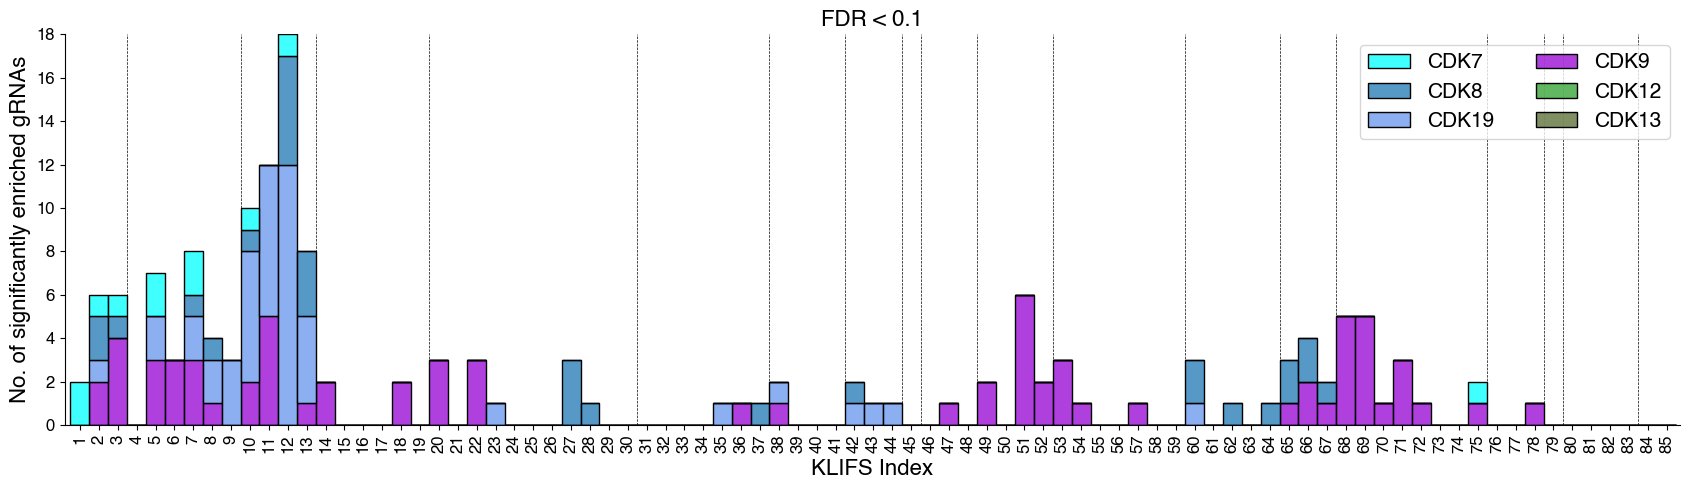

In [ ]:
fig, ax = plt.subplots(figsize=(17,5))

color_dict = {'CDK7':'cyan', 
              'CDK8':'tab:blue', 
              'CDK19':'cornflowerblue', 
              'CDK9':'darkviolet', 
              'CDK12':'tab:green', 
              'CDK13':'darkolivegreen'}

palette = list(color_dict.values())

hue_order = list(color_dict.keys())

sns.histplot(data = melted_UP, bins = np.linspace(1,85,85), x = 'KLIFS Index',  ax=ax, weights='value', hue='variable', multiple='stack',discrete=True, legend=True, palette=palette, hue_order=hue_order)
#sns.stripplot(data = combined_klifs_edit, x = 'KLIFS Index', y='No. of gRNAs Targeting Codon', hue='Gene')


sns.move_legend(ax, "upper right", fontsize=15, ncols=2, title='')

ax.set_xlim(0.2,85.7)
ax.set_ylabel('No. of significantly enriched gRNAs', fontsize=16)
#ax.legend(fontsize=18)
ax.spines[['right', 'top']].set_visible(False)
ax.tick_params(axis='both', which='major', labelsize=12)
ax.set_xticks(list(range(1,86)))
ax.set_xticklabels(list(range(1,86)), rotation=90)
ax.set_xlabel('KLIFS Index', fontsize=16)
#ax.set_title(f'Observed Resistance Mutations (OncoKB R1 & R2) n= {sum(melt_plot["count"])}', fontsize=16)
ax.set_title(f'FDR < {FDR_cutoff}', fontsize=16)
#sns.move_legend(ax, "center right")

ax.set_ylim(0,18)

locs = np.asarray([3.5, 9.5, 13.5, 19.5, 30.5, 37.5, 41.5, 44.5, 45.5, 48.5, 52.5, 59.5, 64.5, 67.5, 75.5, 78.5, 79.5, 83.5])
for i in locs:
    ax.axvline(i, linestyle='dashed', color='black', linewidth=0.5)

fig.tight_layout()
#fig.savefig(f'../../figures/sig_up_FDR_{FDR_cutoff}_by_gene_T0.pdf', transparent=True)

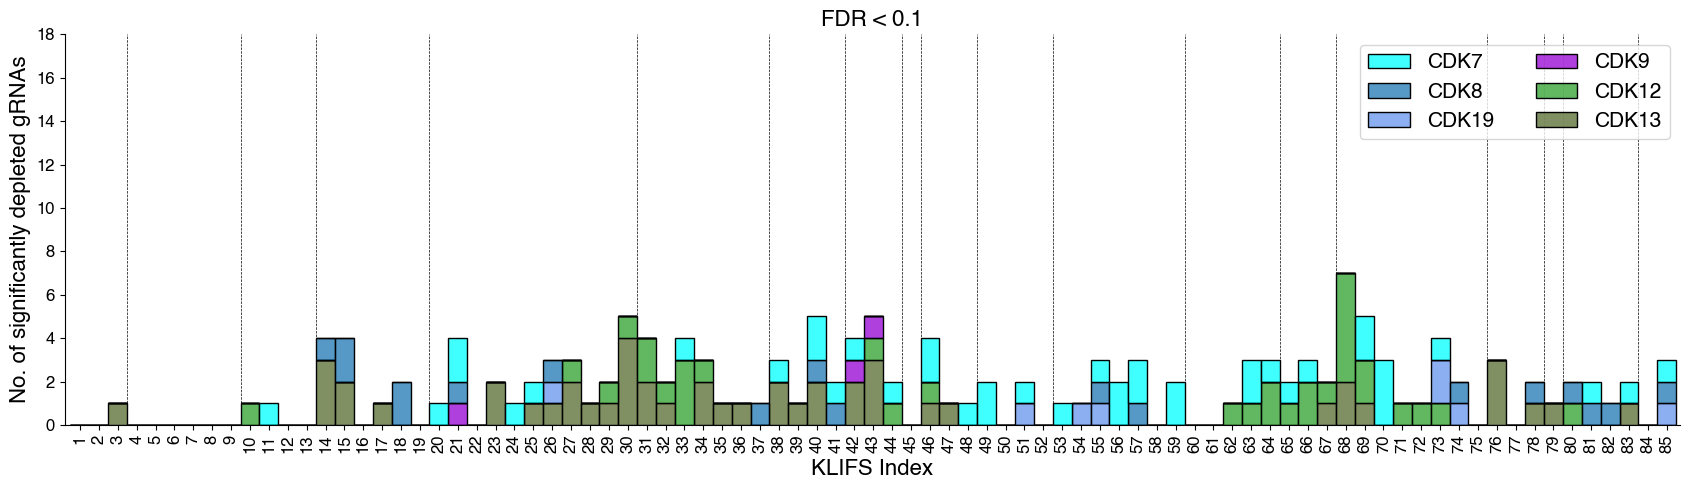

In [ ]:
fig, ax = plt.subplots(figsize=(17,5))

color_dict = {'CDK7':'cyan', 
              'CDK8':'tab:blue', 
              'CDK19':'cornflowerblue', 
              'CDK9':'darkviolet', 
              'CDK12':'tab:green', 
              'CDK13':'darkolivegreen'}

palette = list(color_dict.values())

hue_order = list(color_dict.keys())

sns.histplot(data = melted_DOWN, bins = np.linspace(1,85,85), x = 'KLIFS Index',  ax=ax, weights='value', hue='variable', multiple='stack',discrete=True, legend=True, palette=palette, hue_order=hue_order)
#sns.stripplot(data = combined_klifs_edit, x = 'KLIFS Index', y='No. of gRNAs Targeting Codon', hue='Gene')


sns.move_legend(ax, "upper right", fontsize=15, ncols=2, title='')

ax.set_xlim(0.2,85.7)
ax.set_ylabel('No. of significantly depleted gRNAs', fontsize=16)
#ax.legend(fontsize=18)
ax.spines[['right', 'top']].set_visible(False)
ax.tick_params(axis='both', which='major', labelsize=12)
ax.set_xticks(list(range(1,86)))
ax.set_xticklabels(list(range(1,86)), rotation=90)
ax.set_xlabel('KLIFS Index', fontsize=16)
#ax.set_title(f'Observed Resistance Mutations (OncoKB R1 & R2) n= {sum(melt_plot["count"])}', fontsize=16)
ax.set_title(f'FDR < {FDR_cutoff}', fontsize=16)
#sns.move_legend(ax, "center right")

ax.set_ylim(0,18)


locs = np.asarray([3.5, 9.5, 13.5, 19.5, 30.5, 37.5, 41.5, 44.5, 45.5, 48.5, 52.5, 59.5, 64.5, 67.5, 75.5, 78.5, 79.5, 83.5])
for i in locs:
    ax.axvline(i, linestyle='dashed', color='black', linewidth=0.5)

fig.tight_layout()
#fig.savefig(f'../../figures/sig_down_FDR_{FDR_cutoff}_by_gene_T0.pdf', transparent=True)

In [250]:
min_edit = 50

genes = ['CDK7', 'CDK8', 'CDK9', 'CDK19']
CBE_rg_dict1, ABE_rg_dict1 = rg_dict_gen(SAV_ABE1, SAV_CBE1, genes, min_edit)

genes = ['CDK12', 'CDK13']
CBE_rg_dict2, ABE_rg_dict2 = rg_dict_gen(SAV_ABE2, SAV_CBE2, genes, min_edit)



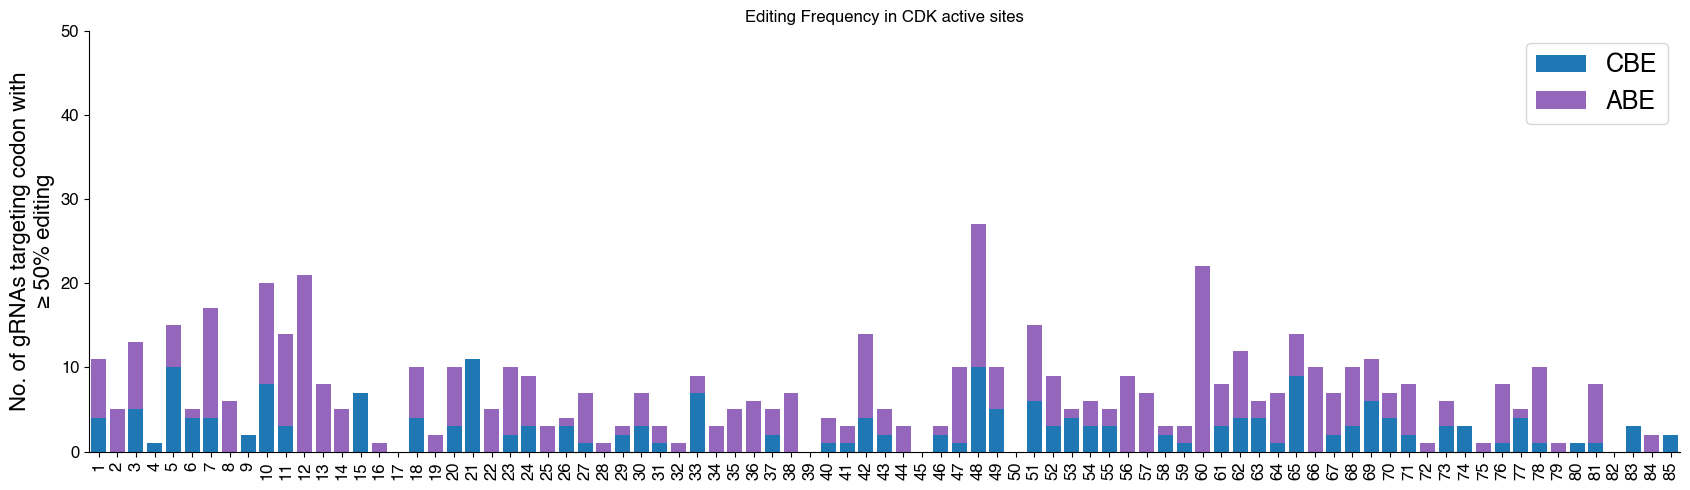

In [255]:

gene = []
cbe_h = []
abe_h = []


for i in CBE_rg_dict1.keys():
    gene.append(i)
    cc = [len(i) for i in CBE_rg_dict1[i]]
    aa = [len(i) for i in ABE_rg_dict1[i]]
    cbe_h.append(cc)
    abe_h.append(aa)


for i in CBE_rg_dict2.keys():
    gene.append(i)
    cc = [len(i) for i in CBE_rg_dict2[i]]
    aa = [len(i) for i in ABE_rg_dict2[i]]
    cbe_h.append(cc)
    abe_h.append(aa)

#-------plotting
num_muts_cbe = pd.DataFrame(dict(zip(gene, cbe_h)))
num_muts_abe = pd.DataFrame(dict(zip(gene, abe_h)))

a_total = num_muts_abe.sum(axis=1)
c_total = num_muts_cbe.sum(axis=1)

fig, ax = plt.subplots(figsize=(17,5))

ax.bar(range(1,86), c_total , color='tab:blue', label='CBE')
ax.bar(range(1,86), a_total, bottom = c_total , color='tab:purple', label='ABE')

ax.set_xlim(0.5,85.5)
ax.set_ylabel(f'No. of gRNAs targeting codon with\n≥ {min_edit}% editing', fontsize=16)

ax.spines[['right', 'top']].set_visible(False)
ax.tick_params(axis='both', which='major', labelsize=12)
ax.set_xticks(list(range(1,86)))
ax.set_xticklabels(list(range(1,86)), rotation=90)
ax.set_ylim(0,50)
ax.legend(fontsize=18)
ax.set_title('Editing Frequency in CDK active sites')
fig.tight_layout()
fig.savefig(f'../../figures/KLIFS_{min_edit}_editing.pdf', transparent=True)

In [253]:
num_muts_abe['KLIFS Index'] = list(range(1,86))
num_muts_cbe['KLIFS Index'] = list(range(1,86))

num_muts_abe = num_muts_abe.melt(id_vars = ('KLIFS Index')).rename(columns={'variable':'Gene', 'value':'No. of gRNAs Targeting Codon'})
num_muts_cbe = num_muts_cbe.melt(id_vars = ('KLIFS Index')).rename(columns={'variable':'Gene', 'value':'No. of gRNAs Targeting Codon'})

num_muts_abe['Editor'] = 'ABE'
num_muts_cbe['Editor'] = 'CBE'

combined_klifs_edit = pd.concat((num_muts_abe, num_muts_cbe))



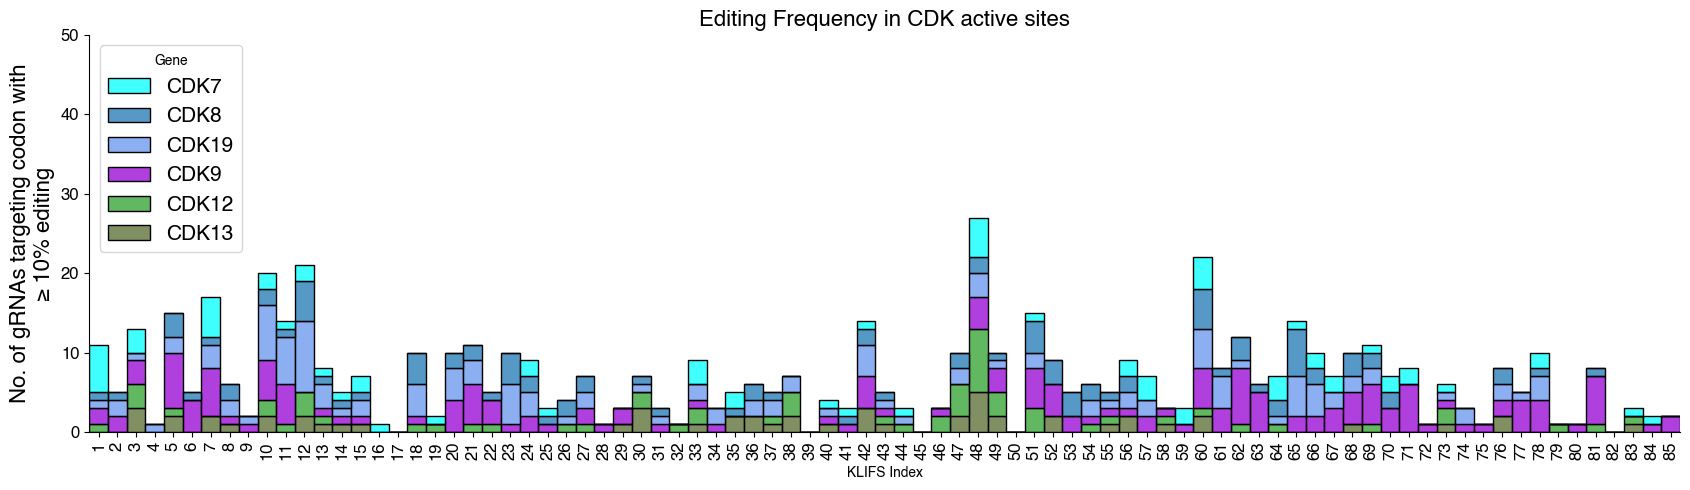

In [327]:
#ax = sns.histplot(co, x='Date', hue='Type', weights='Value', multiple='stack')

color_dict = {'CDK7':'cyan', 
              'CDK8':'tab:blue', 
              'CDK19':'cornflowerblue', 
              'CDK9':'darkviolet', 
              'CDK12':'tab:green', 
              'CDK13':'darkolivegreen'}

palette = list(color_dict.values())

hue_order = list(color_dict.keys())



fig, ax = plt.subplots(figsize=(17,5))

sns.histplot(data = combined_klifs_edit, bins = np.linspace(1,85,85), x = 'KLIFS Index',  ax=ax, weights='No. of gRNAs Targeting Codon', hue='Gene', multiple='stack', hue_order = hue_order, palette=palette, discrete=True, legend=True)
#sns.stripplot(data = combined_klifs_edit, x = 'KLIFS Index', y='No. of gRNAs Targeting Codon', hue='Gene')

ax.set_xlim(0.5,85.5)
ax.set_ylabel(f'No. of gRNAs targeting codon with\n≥ {min_edit}% editing', fontsize=16)
ax.set_ylim(0,50)

sns.move_legend(ax, "upper left", fontsize=15)

ax.spines[['right', 'top']].set_visible(False)
ax.tick_params(axis='both', which='major', labelsize=12)
ax.set_xticks(list(range(1,86)))
ax.set_xticklabels(list(range(1,86)), rotation=90)
ax.set_title('Editing Frequency in CDK active sites', fontsize=16)
fig.tight_layout()
#fig.savefig(f'../../figures/editing_by_cdk_flifs_{min_edit}.pdf', transparent=True)


# Lollipop Plots

In [402]:
min_edit = 10
genes = ['CDK7', 'CDK8', 'CDK9', 'CDK19']
CBE_rg_dict1, ABE_rg_dict1 = rg_dict_gen(SAV_ABE1, SAV_CBE1, genes, min_edit)

genes = ['CDK12', 'CDK13']
CBE_rg_dict2, ABE_rg_dict2 = rg_dict_gen(SAV_ABE2, SAV_CBE2, genes, min_edit)

In [405]:
ABE = pd.read_csv('../../screening_data/03_LFC_FDR_tables/barcode_counts/DMSO_base/SY_5609_ABE_barcode_DMSO_base.csv')
CBE = pd.read_csv('../../screening_data/03_LFC_FDR_tables/barcode_counts/DMSO_base/SY_5609_CBE_barcode_DMSO_base.csv')


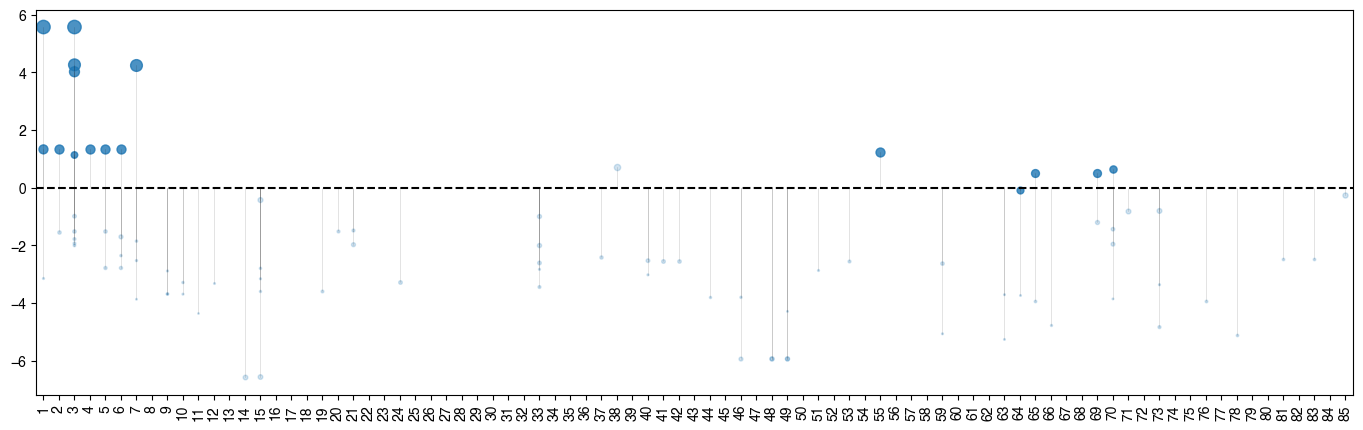

In [416]:
fig, ax = plt.subplots(figsize=(17,5))

condition = 'SY-5609_100nM'
name_CBE = f'LFC_median_CBE_{condition}'
FDR_CBE = f'FDR_CBE_{condition}'

for i, val in enumerate(CBE_rg_dict1['CDK7']):

    s = CBE[CBE['gRNA_id'].isin(val)]

    bb1 = s[(s[FDR_CBE]>=FDR_cutoff)]
    bb2 = s[(s[FDR_CBE]<FDR_cutoff)]

    ax.scatter([i+1]*len(bb1), bb1[name_CBE], s = 20*-np.log10(bb1[FDR_CBE])+1, alpha=.2, color='tab:blue')
    ax.scatter([i+1]*len(bb2), bb2[name_CBE], s = 20*-np.log10(bb2[FDR_CBE])+1, alpha=.8, color='tab:blue')

    for iii, val in bb2.iterrows():
        ax.plot([i+1, i+1], [0,val[name_CBE]], linewidth=.4, color='black', alpha=.2)
    for iii, val in bb1.iterrows():
        ax.plot([i+1, i+1], [0,val[name_CBE]], linewidth=.4, color='black', alpha=.2)


ax.axhline(0, color='black', linestyle='dashed')
ax.set_xlim(0.5, 85.5)
ax.set_xticks(list(range(1,86)))
ax.set_xticklabels(list(range(1,86)), rotation=90);

In [417]:
ABE = pd.read_csv('../../screening_data/03_LFC_FDR_tables/barcode_counts/DMSO_base/ABE_subpool1_barcode_DMSO_base.csv')
CBE = pd.read_csv('../../screening_data/03_LFC_FDR_tables/barcode_counts/DMSO_base/CBE_subpool1_barcode_DMSO_base.csv')

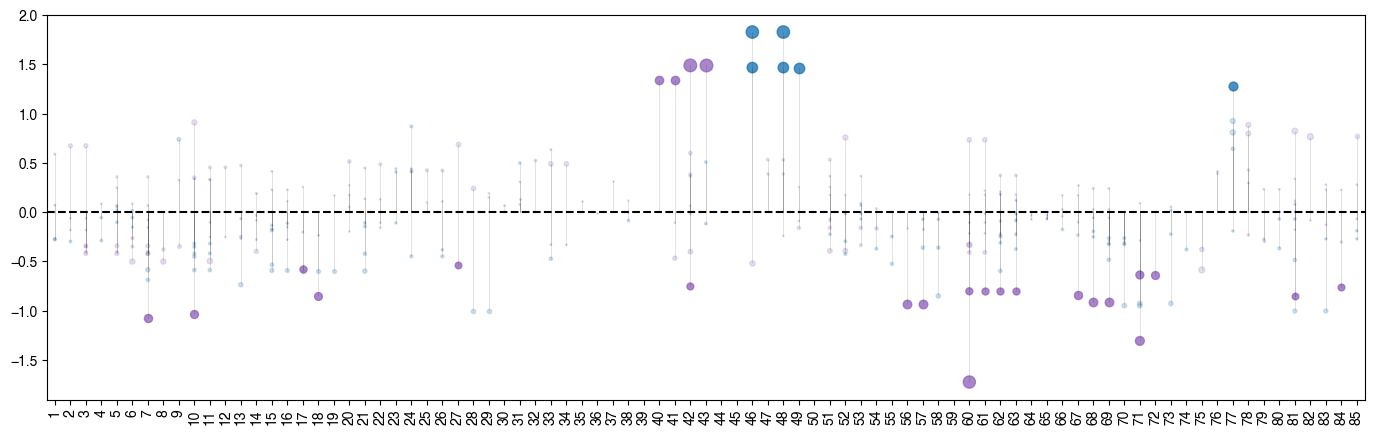

In [467]:
fig, ax = plt.subplots(figsize=(17,5))

FDR_cutoff = 0.1

condition = 'KI-CDK9d-32N_1250nM'
name_CBE = f'LFC_median_{condition}'
FDR_CBE = f'FDR_{condition}'
FDR_ABE = FDR_CBE
name_ABE = name_CBE

gene = 'CDK9'

for i, val in enumerate(CBE_rg_dict1[gene]):

    

    s = CBE[CBE['gRNA_id'].isin(val)]

    bb1 = s[(s[FDR_CBE]>=FDR_cutoff)]
    bb2 = s[(s[FDR_CBE]<FDR_cutoff)]


    ax.scatter([i+1]*len(bb1), bb1[name_CBE], s = 20*-np.log10(bb1[FDR_CBE])+1, alpha=.2, color='tab:blue')
    ax.scatter([i+1]*len(bb2), bb2[name_CBE], s = 20*-np.log10(bb2[FDR_CBE])+1, alpha=.8, color='tab:blue')

    for iii, val in bb2.iterrows():
        ax.plot([i+1, i+1], [0,val[name_CBE]], linewidth=.4, color='black', alpha=.2)
    for iii, val in bb1.iterrows():
        ax.plot([i+1, i+1], [0,val[name_CBE]], linewidth=.4, color='black', alpha=.2)

for i, val in enumerate(ABE_rg_dict1[gene]):

    s = ABE[ABE['gRNA_id'].isin(val)]

    bb1 = s[(s[FDR_ABE]>=FDR_cutoff)]
    bb2 = s[(s[FDR_ABE]<FDR_cutoff)]

    ax.scatter([i+1]*len(bb1), bb1[name_ABE], s = 20*-np.log10(bb1[FDR_ABE])+1, alpha=.2, color='tab:purple')
    ax.scatter([i+1]*len(bb2), bb2[name_ABE], s = 20*-np.log10(bb2[FDR_ABE])+1, alpha=.8, color='tab:purple')

    for iii, val in bb2.iterrows():
        ax.plot([i+1, i+1], [0,val[name_ABE]], linewidth=.4, color='black', alpha=.2)
    for iii, val in bb1.iterrows():
        ax.plot([i+1, i+1], [0,val[name_ABE]], linewidth=.4, color='black', alpha=.2)


ax.axhline(0, color='black', linestyle='dashed')
ax.set_xlim(0.5, 85.5)
ax.set_xticks(list(range(1,86)))
ax.set_xticklabels(list(range(1,86)), rotation=90);

# Correlation T0 vs. conditions

In [621]:
min_edit = 10
genes = ['CDK7', 'CDK8', 'CDK9', 'CDK19']
CBE_rg_dict1, ABE_rg_dict1 = rg_dict_gen(SAV_ABE1, SAV_CBE1, genes, min_edit)

genes = ['CDK12', 'CDK13']
CBE_rg_dict2, ABE_rg_dict2 = rg_dict_gen(SAV_ABE2, SAV_CBE2, genes, min_edit)

In [631]:
ABE_s1_plasmid = pd.read_csv('../../screening_data/03_LFC_FDR_tables/barcode_counts/Plasmid_base/ABE_subpool1_barcode_Plasmid_base.csv')
CBE_s1_plasmid = pd.read_csv('../../screening_data/03_LFC_FDR_tables/barcode_counts/Plasmid_base/CBE_subpool1_barcode_Plasmid_base.csv')

ABE_s2_plasmid = pd.read_csv('../../screening_data/03_LFC_FDR_tables/barcode_counts/Plasmid_base/CDK12_13_ABE_barcode_Plasmid_base.csv')
CBE_s2_plasmid = pd.read_csv('../../screening_data/03_LFC_FDR_tables/barcode_counts/Plasmid_base/CDK12_13_CBE_barcode_Plasmid_base.csv')


ABE_s1 = pd.read_csv('../../screening_data/03_LFC_FDR_tables/barcode_counts/DMSO_base/ABE_subpool1_barcode_DMSO_base.csv')
CBE_s1 = pd.read_csv('../../screening_data/03_LFC_FDR_tables/barcode_counts/DMSO_base/CBE_subpool1_barcode_DMSO_base.csv')


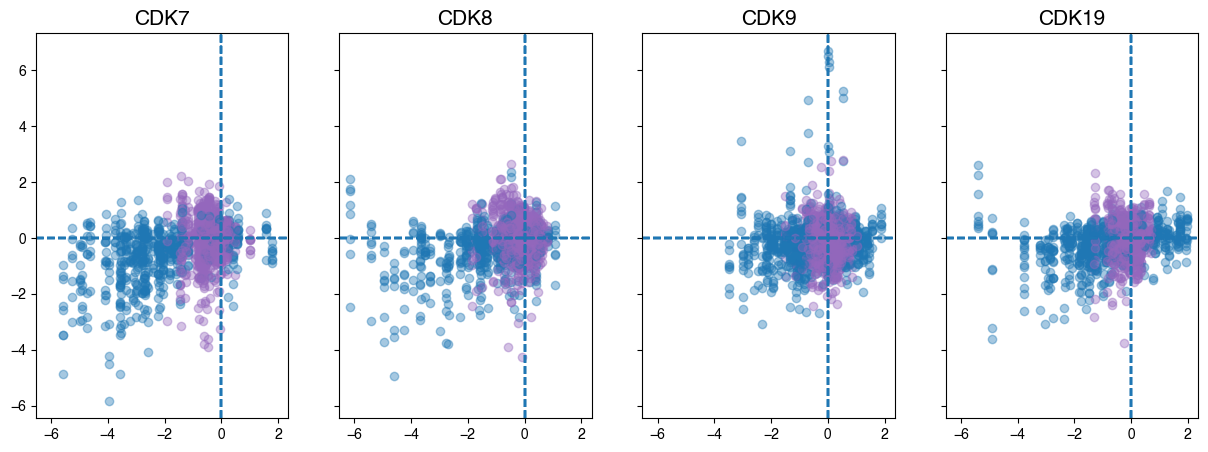

In [674]:

fig, ax = plt.subplots(1,4,figsize=(15,5), sharex=True, sharey=True)


genes = ['CDK7', 'CDK8', 'CDK9', 'CDK19']

condition = 'KI-CDK9d-32N_5000nM'

conditions = ['Senexin B_15000nM', 'Senexin B_2000nM', 'KI-CDK9d-32_100nM', 'KI-CDK9d-32_1000nM', 'KI-CDK9d-32N_1250nM', 'KI-CDK9d-32N_5000nM', 'SEL120_4000nM', 'KB-0742_1500nM']

p = []
c = []
e = []
cond1 = []
gg = []

for condition in conditions:

    for i, val in enumerate(genes):
        aa = CBE_rg_dict1[val]
        flat_list = [x for xs in aa for x in xs]
        np.unique(flat_list)

        plas = CBE_s1_plasmid[CBE_s1_plasmid['gRNA_id'].isin(np.unique(flat_list))]
        cond = CBE_s1[CBE_s1['gRNA_id'].isin(np.unique(flat_list))]
        assert list(plas['gRNA_id'])==list(cond['gRNA_id'])

        ax[i].scatter(plas['LFC_median_T0'], cond[f'LFC_median_{condition}'], c='tab:blue', alpha=.4)
        ax[i].set_title(val, fontsize=15)
        ax[i].axvline(0, linestyle='dashed')
        ax[i].axhline(0, linestyle='dashed')

        for j in plas['LFC_median_T0']:
            p.append(j)
        for j in cond[f'LFC_median_{condition}']:
            c.append(j)
            cond1.append(condition)
            e.append('CBE')
            gg.append(val)
        


    for i, val in enumerate(genes):
        aa = ABE_rg_dict1[val]
        flat_list = [x for xs in aa for x in xs]
        np.unique(flat_list)

        plas = ABE_s1_plasmid[ABE_s1_plasmid['gRNA_id'].isin(np.unique(flat_list))]
        cond = ABE_s1[ABE_s1['gRNA_id'].isin(np.unique(flat_list))]
        assert list(plas['gRNA_id'])==list(cond['gRNA_id'])

        ax[i].scatter(plas['LFC_median_T0'], cond[f'LFC_median_{condition}'],c='tab:purple', alpha=.4)
        ax[i].set_title(val, fontsize=15)
        ax[i].axvline(0, linestyle='dashed')
        ax[i].axhline(0, linestyle='dashed')

        for j in plas['LFC_median_T0']:
            p.append(j)
        for j in cond[f'LFC_median_{condition}']:
            c.append(j)
            cond1.append(condition)
            e.append('ABE')
            gg.append(val)


In [ ]:

fig, ax = plt.subplots(1,4,figsize=(15,5), sharex=True, sharey=True)


genes = ['CDK12', 'CDK13']

condition = 'KI-CDK9d-32N_5000nM'

conditions = ['Senexin B_15000nM', 'Senexin B_2000nM', 'KI-CDK9d-32_100nM', 'KI-CDK9d-32_1000nM', 'KI-CDK9d-32N_1250nM', 'KI-CDK9d-32N_5000nM', 'SEL120_4000nM', 'KB-0742_1500nM']

p = []
c = []
e = []
cond1 = []
gg = []

for condition in conditions:

    for i, val in enumerate(genes):
        aa = CBE_rg_dict1[val]
        flat_list = [x for xs in aa for x in xs]
        np.unique(flat_list)

        plas = CBE_s1_plasmid[CBE_s1_plasmid['gRNA_id'].isin(np.unique(flat_list))]
        cond = CBE_s1[CBE_s1['gRNA_id'].isin(np.unique(flat_list))]
        assert list(plas['gRNA_id'])==list(cond['gRNA_id'])

        ax[i].scatter(plas['LFC_median_T0'], cond[f'LFC_median_{condition}'], c='tab:blue', alpha=.4)
        ax[i].set_title(val, fontsize=15)
        ax[i].axvline(0, linestyle='dashed')
        ax[i].axhline(0, linestyle='dashed')

        for j in plas['LFC_median_T0']:
            p.append(j)
        for j in cond[f'LFC_median_{condition}']:
            c.append(j)
            cond1.append(condition)
            e.append('CBE')
            gg.append(val)
        


    for i, val in enumerate(genes):
        aa = ABE_rg_dict1[val]
        flat_list = [x for xs in aa for x in xs]
        np.unique(flat_list)

        plas = ABE_s1_plasmid[ABE_s1_plasmid['gRNA_id'].isin(np.unique(flat_list))]
        cond = ABE_s1[ABE_s1['gRNA_id'].isin(np.unique(flat_list))]
        assert list(plas['gRNA_id'])==list(cond['gRNA_id'])

        ax[i].scatter(plas['LFC_median_T0'], cond[f'LFC_median_{condition}'],c='tab:purple', alpha=.4)
        ax[i].set_title(val, fontsize=15)
        ax[i].axvline(0, linestyle='dashed')
        ax[i].axhline(0, linestyle='dashed')

        for j in plas['LFC_median_T0']:
            p.append(j)
        for j in cond[f'LFC_median_{condition}']:
            c.append(j)
            cond1.append(condition)
            e.append('ABE')
            gg.append(val)

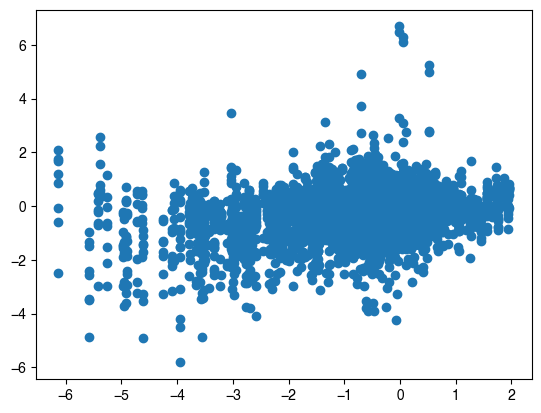

In [679]:
aa = pd.DataFrame(dict(zip(['Gene', 'Editor', 'Condition', 'T0_plasmid', 'Condition_LFC'], [gg, e, cond1, p, c])))


scipy.stats.pearsonr(aa['T0_plasmid'], aa['Condition_LFC'])

plt.scatter(aa['T0_plasmid'], aa['Condition_LFC'])

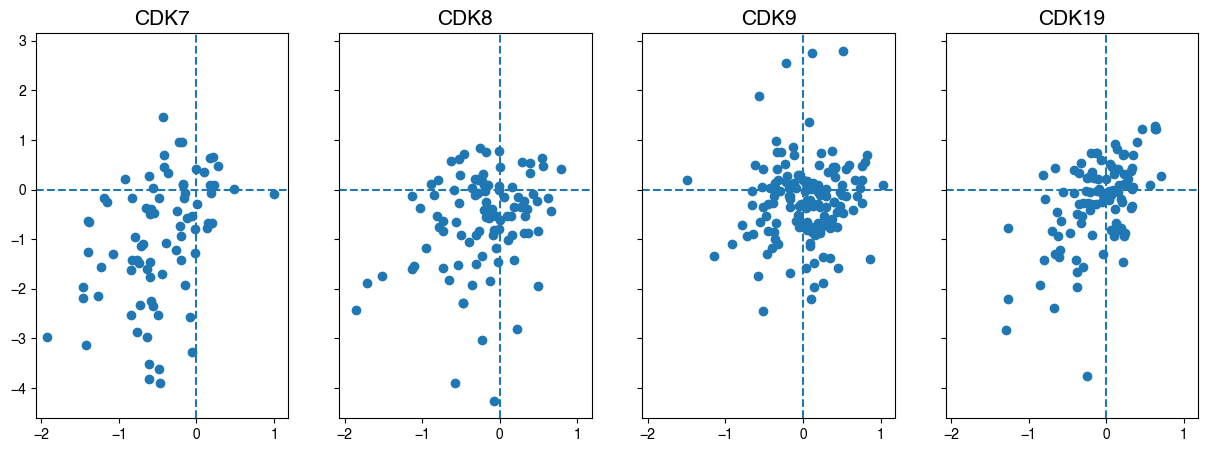

In [666]:

fig, ax = plt.subplots(1,4,figsize=(15,5), sharex=True, sharey=True)


genes = ['CDK7', 'CDK8', 'CDK9', 'CDK19']

condition = 'KI-CDK9d-32N_5000nM'



for i, val in enumerate(genes):
    aa = ABE_rg_dict1[val]
    flat_list = [x for xs in aa for x in xs]
    np.unique(flat_list)

    plas = ABE_s1_plasmid[ABE_s1_plasmid['gRNA_id'].isin(np.unique(flat_list))]
    cond = ABE_s1[ABE_s1['gRNA_id'].isin(np.unique(flat_list))]
    assert list(plas['gRNA_id'])==list(cond['gRNA_id'])

    ax[i].scatter(plas['LFC_median_T0'], cond[f'LFC_median_{condition}'])
    ax[i].set_title(val, fontsize=15)
    ax[i].axvline(0, linestyle='dashed')
    ax[i].axhline(0, linestyle='dashed')

In [462]:
ABE_s1[(ABE_s1['gRNA_id'].isin(ABE_rg_dict1['CDK7'][4]))][[f'FDR_{condition}', f'LFC_median_{condition}']]

,FDR_KI-CDK9d-32N_1250nM,LFC_median_KI-CDK9d-32N_1250nM
19,0.246074,0.464916
20,0.743122,-0.019750
21,0.873602,-0.807275
237,1.000000,-0.709388


In [459]:
ABE_s1[(ABE_s1['gRNA_id'].isin(ABE_rg_dict1['CDK7'][4])) & (ABE_s1[f'FDR_{condition}']<FDR_cutoff)] #[[f'FDR_{condition}', f'LFC_median_{condition}']]

,gRNA_id,Gene,classification,DMSO_REP1,DMSO_REP2,DMSO_REP3,LFC_avg_DMSO,LFC_median_DMSO,base_RPM,base_RAW,...,p_KI-CDK9d-32_100nM,FDR_KI-CDK9d-32_100nM,p_SEL120_4000nM,FDR_SEL120_4000nM,p_Senexin B_15000nM,FDR_Senexin B_15000nM,p_Senexin B_2000nM,FDR_Senexin B_2000nM,p_T0,FDR_T0


# Somatic Variation (Genie)

In [547]:
genie = pd.read_csv('/Users/samgould/Desktop/FSR Lab/reference files/aacr-genie-17.0/data_mutations_extended.txt', sep='\t')

In [690]:
cdks = ['CDK7', 'CDK8', 'CDK9', 'CDK19', 'CDK12', 'CDK13', 'CDK2', 'CDK4', 'CDK6']
genie_cdks = genie[genie['Hugo_Symbol'].isin(cdks)].reset_index(drop=True)

#drop values not in coding sequence
genie_cdks = genie_cdks.dropna(subset='HGVSp').reset_index(drop=True)

inc_genes = list(np.unique(genie_cdks['Hugo_Symbol']))

In [695]:
import re

def extract_numbers(text):
    """Extracts all numbers from the given text."""
    return [int(i) for i in re.findall(r'\d+', text)][0]

genie_cdks['Codon'] = [extract_numbers(i) for i in genie_cdks['HGVSp']]
genie_cdks

,Hugo_Symbol,Entrez_Gene_Id,Center,NCBI_Build,Chromosome,Start_Position,End_Position,Strand,Consequence,Variant_Classification,...,Polyphen_Prediction,Polyphen_Score,SIFT_Prediction,SIFT_Score,SWISSPROT,n_depth,t_depth,Annotation_Status,mutationInCis_Flag,Codon
0,CDK12,51755.0,DFCI,GRCh37,17,37649017,37649017,+,missense_variant,Missense_Mutation,...,probably_damaging,0.996,deleterious,0.00,NaN,NaN,251.0,SUCCESS,False,708
1,CDK12,51755.0,DFCI,GRCh37,17,37618717,37618717,+,missense_variant,Missense_Mutation,...,probably_damaging,0.952,tolerated_low_confidence,0.21,NaN,NaN,417.0,SUCCESS,False,131
2,CDK12,51755.0,DFCI,GRCh37,17,37682416,37682416,+,missense_variant,Missense_Mutation,...,benign,0.039,tolerated_low_confidence,0.07,NaN,NaN,297.0,SUCCESS,False,1203
3,CDK8,1024.0,DFCI,GRCh37,13,26828814,26828814,+,missense_variant,Missense_Mutation,...,benign,0.003,tolerated,0.20,NaN,NaN,286.0,SUCCESS,False,12
4,CDK12,51755.0,DFCI,GRCh37,17,37682446,37682446,+,missense_variant,Missense_Mutation,...,benign,0.000,deleterious_low_confidence,0.03,NaN,NaN,464.0,SUCCESS,False,1213
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8292,CDK12,51755.0,PROV,GRCh37,17,37618619,37618619,+,missense_variant,Missense_Mutation,...,probably_damaging,0.988,deleterious_low_confidence,0.00,NaN,NaN,4686.0,SUCCESS,False,99
8293,CDK6,1021.0,PROV,GRCh37,7,92252390,92252390,+,missense_variant,Missense_Mutation,...,benign,0.022,tolerated,0.15,NaN,NaN,3320.0,SUCCESS,False,220
8294,CDK12,51755.0,PROV,GRCh37,17,37646946,37646946,+,missense_variant,Missense_Mutation,...,benign,0.035,tolerated,0.18,NaN,NaN,3746.0,SUCCESS,False,690
8295,CDK12,51755.0,PROV,GRCh37,17,37686995,37686995,+,missense_variant,Missense_Mutation,...,possibly_damaging,0.897,deleterious_low_confidence,0.00,NaN,NaN,4280.0,SUCCESS,False,1300


In [708]:
KLIFS = pd.read_csv('../../source_data/16_KLIFS/KLIFS_compiled.csv')
KLIFS2 = KLIFS.copy()


for g in inc_genes:
    KLIFS2[f'{g}_muts'] = 0

for g in inc_genes:
    subset = genie_cdks[(genie_cdks['Hugo_Symbol']==g) & (genie_cdks['Codon'].isin(KLIFS2[g]))]

    for i, val in subset.iterrows():
        KLIFS2.loc[KLIFS2[g]==val['Codon'], f'{g}_muts'] += 1


In [723]:
k2 = KLIFS2[['CDK12_muts', 'CDK2_muts', 'CDK4_muts', 'CDK6_muts', 'CDK8_muts','CDK9_muts']]

k2['KLIFS Index'] = list(range(1,86))

col_dict = dict(zip(['CDK12_muts', 'CDK2_muts', 'CDK4_muts', 'CDK6_muts', 'CDK8_muts','CDK9_muts'], ['CDK12', 'CDK2', 'CDK4', 'CDK6', 'CDK8','CDK9']))
k2 = k2.rename(columns = col_dict)
m1 = k2.melt(id_vars = ('KLIFS Index')).rename(columns={'variable':'Gene', 'value':'No. of Observed Mutations'})
m1

,KLIFS Index,Gene,No. of Observed Mutations
0,1,CDK12,2
1,2,CDK12,1
2,3,CDK12,1
3,4,CDK12,7
4,5,CDK12,4
...,...,...,...
505,81,CDK9,0
506,82,CDK9,0
507,83,CDK9,0
508,84,CDK9,0


In [730]:
sum(m1['No. of Observed Mutations'])

1160

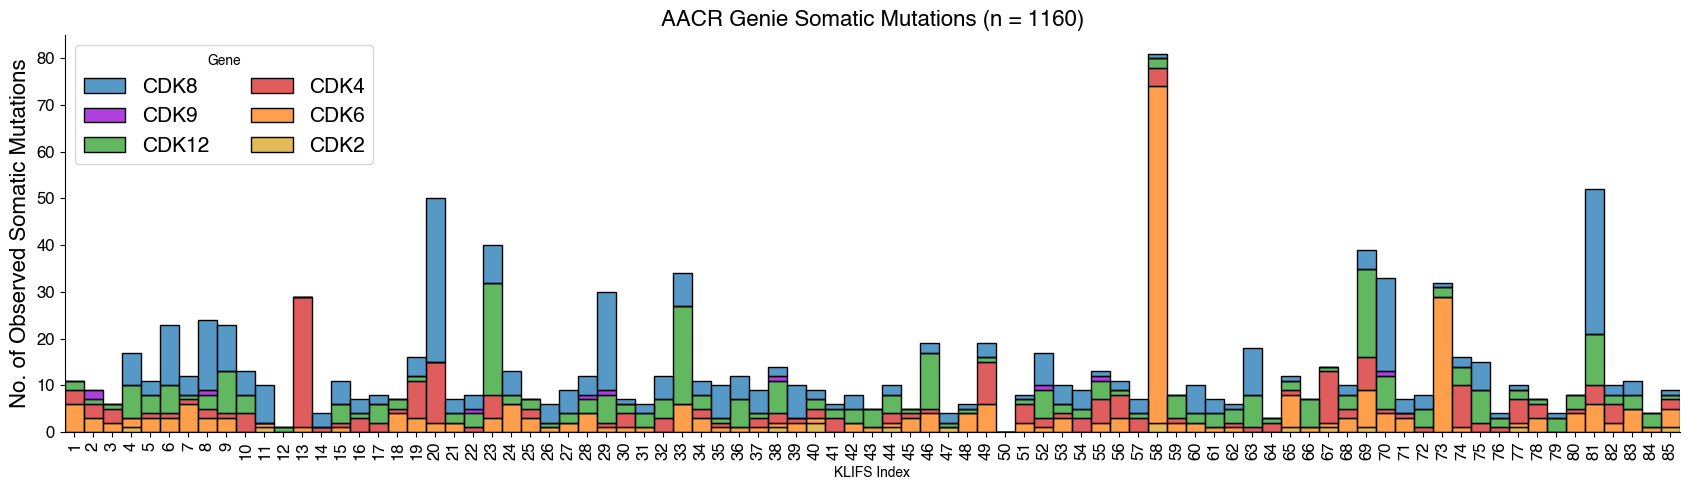

In [ ]:
fig, ax = plt.subplots(figsize=(17,5))


color_dict = {
              'CDK8':'tab:blue', 
              'CDK9':'darkviolet', 
              'CDK12':'tab:green', 
              'CDK4':'tab:red', 
              'CDK6':'tab:orange', 
              'CDK2':'goldenrod'}


palette = list(color_dict.values())

hue_order = list(color_dict.keys())

sns.histplot(data = m1, bins = np.linspace(1,85,85), x = 'KLIFS Index', ax=ax, weights='No. of Observed Mutations', hue='Gene', multiple='stack', discrete=True, legend=True,hue_order=hue_order, palette=palette)

ax.set_xlim(0.5,85.5)
ax.set_ylabel(f'No. of Observed Somatic Mutations', fontsize=16)

sns.move_legend(ax, "upper left", fontsize=15, ncols=2)

ax.spines[['right', 'top']].set_visible(False)
ax.tick_params(axis='both', which='major', labelsize=12)
ax.set_xticks(list(range(1,86)))
ax.set_xticklabels(list(range(1,86)), rotation=90)
ax.set_title(f'AACR Genie Somatic Mutations (n = {sum(m1["No. of Observed Mutations"])})', fontsize=16)
fig.tight_layout()
#fig.savefig('../../figures/somatic_muts_KLIFS.pdf', transparent=True)

In [ ]:
KLIFS = pd.read_csv('../../source_data/16_KLIFS/KLIFS_compiled.csv')

KLIFS2 = KLIFS.copy()

for gene in inc_genes:
    KLIFS2[gene]

,KLIFS_idx,CDK7,CDK7_seq,CDK8,CDK8_seq,CDK19,CDK19_seq,CDK9,CDK9_seq,CDK12,CDK12_seq,CDK13,CDK13_seq,CDK2,CDK2_seq,CDK4,CDK4_seq,CDK6,CDK6_seq
0,I:1,16.0,D,25.0,C,25.0,C,23.0,A,731.0,G,709.0,G,8.0,E,10.0,A,17.0,A
1,I:2,17.0,F,26.0,K,26.0,K,24.0,K,732.0,I,710.0,I,9.0,K,11.0,E,18.0,E
2,I:3,18.0,L,27.0,V,27.0,V,25.0,I,733.0,I,711.0,I,10.0,I,12.0,I,19.0,I
3,g.l:4,19.0,G,28.0,G,28.0,G,26.0,G,734.0,G,712.0,G,11.0,G,13.0,G,20.0,G
4,g.l:5,20.0,E,29.0,R,29.0,R,27.0,Q,735.0,E,713.0,E,12.0,E,14.0,V,21.0,E
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
80,xDFG:81,155.0,D,173.0,D,173.0,D,167.0,D,877.0,D,855.0,D,145.0,D,158.0,D,163.0,D
81,xDFG:82,156.0,F,174.0,M,174.0,M,168.0,F,878.0,F,856.0,F,146.0,F,159.0,F,164.0,F
82,xDFG:83,157.0,G,175.0,G,175.0,G,169.0,G,879.0,G,857.0,G,147.0,G,160.0,G,165.0,G
83,a.l:84,158.0,L,176.0,F,176.0,F,170.0,L,880.0,L,858.0,L,148.0,L,161.0,L,166.0,L


In [696]:
KLIFS2[gene]

0      23.0
1      24.0
2      25.0
3      26.0
4      27.0
      ...  
80    167.0
81    168.0
82    169.0
83    170.0
84    171.0
Name: CDK9, Length: 85, dtype: float64

In [ ]:
import re

def extract_numbers(text):
    """Extracts all numbers from the given text."""
    return [int(i) for i in re.findall(r'\d+', text)][0]



In [ ]:
for i, val in KLIFS2.iterrows():
    nn = val[gene]
    
    try:
        subset_ABE = list(ABE_s2[ABE_s2['gRNA_id'].isin(a[i])][f'LFC_median_ABE_{condition}'])
        subset_CBE = list(CBE_s2[CBE_s2['gRNA_id'].isin(c[i])][f'LFC_median_CBE_{condition}'])

        #num_sig_ABE = len(ABE_s2[(ABE_s2['gRNA_id'].isin(a[i])) & (ABE_s2[f'FDR_ABE_{condition}']<FDR_cutoff)])
        #num_sig_CBE = len(CBE_s2[(CBE_s2['gRNA_id'].isin(c[i])) & (CBE_s2[f'FDR_CBE_{condition}']<FDR_cutoff)])

        num_sig_ABE_up = len(ABE_s2[(ABE_s2['gRNA_id'].isin(a[i])) & (ABE_s2[f'FDR_ABE_{condition}']<FDR_cutoff) & (ABE_s2[f'LFC_median_ABE_{condition}']>0)])
        num_sig_CBE_up = len(CBE_s2[(CBE_s2['gRNA_id'].isin(c[i])) & (CBE_s2[f'FDR_CBE_{condition}']<FDR_cutoff) & (CBE_s2[f'LFC_median_CBE_{condition}']>0)])
        num_sig_ABE_down = len(ABE_s2[(ABE_s2['gRNA_id'].isin(a[i])) & (ABE_s2[f'FDR_ABE_{condition}']<FDR_cutoff)& (ABE_s2[f'LFC_median_ABE_{condition}']<0)])
        num_sig_CBE_down = len(CBE_s2[(CBE_s2['gRNA_id'].isin(c[i])) & (CBE_s2[f'FDR_CBE_{condition}']<FDR_cutoff) & (CBE_s2[f'LFC_median_CBE_{condition}']<0)])

    except:
        subset_ABE = list(ABE_s2[ABE_s2['gRNA_id'].isin(a[i])][f'LFC_median_{condition}'])
        subset_CBE = list(CBE_s2[CBE_s2['gRNA_id'].isin(c[i])][f'LFC_median_{condition}'])

        num_sig_ABE_up = len(ABE_s2[(ABE_s2['gRNA_id'].isin(a[i])) & (ABE_s2[f'FDR_{condition}']<FDR_cutoff) & (ABE_s2[f'LFC_median_{condition}']>0)])
        num_sig_CBE_up = len(CBE_s2[(CBE_s2['gRNA_id'].isin(c[i])) & (CBE_s2[f'FDR_{condition}']<FDR_cutoff) & (CBE_s2[f'LFC_median_{condition}']>0)])
        num_sig_ABE_down = len(ABE_s2[(ABE_s2['gRNA_id'].isin(a[i])) & (ABE_s2[f'FDR_{condition}']<FDR_cutoff)& (ABE_s2[f'LFC_median_{condition}']<0)])
        num_sig_CBE_down = len(CBE_s2[(CBE_s2['gRNA_id'].isin(c[i])) & (CBE_s2[f'FDR_{condition}']<FDR_cutoff) & (CBE_s2[f'LFC_median_{condition}']<0)])


    total_sig_up = num_sig_ABE_up + num_sig_CBE_up
    total_sig_down = num_sig_ABE_down + num_sig_CBE_down
    comb1 = subset_ABE + subset_CBE

    KLIFS2.loc[KLIFS2[gene]==nn, f'{gene}_guides'] = len(comb1)
    KLIFS2.loc[KLIFS2[gene]==nn, f'{gene}_avg'] = np.average(comb1)
    KLIFS2.loc[KLIFS2[gene]==nn, f'{gene}_num_sig_up'] = total_sig_up
    KLIFS2.loc[KLIFS2[gene]==nn, f'{gene}_num_sig_down'] = total_sig_down

In [572]:
cdks = ['CDK7', 'CDK8', 'CDK9', 'CDK19', 'CDK12', 'CDK13', 'CDK2', 'CDK4', 'CDK6']
genie_cdks = genie[genie['Hugo_Symbol'].isin(cdks)].reset_index(drop=True)


list(genie_cdks[genie_cdks['Hugo_Symbol']=='CDK12']['HGVSp'])
#genie_cdks['HGVSp']



['p.Arg708Cys',
 'p.Glu131Asp',
 'p.Pro1203Ser',
 'p.Leu1213Phe',
 'p.Ala1152Thr',
 'p.Pro1245Leu',
 'p.Glu98Ter',
 'p.His7Arg',
 'p.His7Arg',
 'p.Gln1133Glu',
 nan,
 nan,
 'p.Arg980Met',
 'p.Pro1280Thr',
 nan,
 'p.Leu539Val',
 'p.Leu566Val',
 'p.Gly1446Glu',
 'p.Glu1364Gln',
 'p.Gln244His',
 'p.Pro1273Ser',
 'p.Pro586His',
 'p.Gly1359Val',
 'p.Gln977HisfsTer25',
 'p.Ser590Ter',
 'p.Leu1443Pro',
 'p.Arg773His',
 'p.Pro904Thr',
 'p.Pro282His',
 'p.Ser301Tyr',
 'p.Ser949AlafsTer24',
 'p.Gly1461Cys',
 'p.Arg950Leu',
 'p.Gln570Ter',
 'p.Trp1459Ter',
 'p.Gln1149dup',
 'p.Thr667Ser',
 'p.Gly499Glu',
 'p.Leu866Phe',
 'p.Leu811Phe',
 'p.Pro1273Arg',
 'p.Pro1273Arg',
 'p.Pro1273Arg',
 'p.Pro1273Arg',
 'p.Pro1273Arg',
 'p.Lys965Arg',
 'p.Arg322Gln',
 'p.Leu447Ile',
 'p.Ser345Cys',
 'p.Phe89Leu',
 'p.Ser176Ter',
 'p.Leu395Met',
 'p.Leu123Pro',
 'p.Pro915Ser',
 'p.Arg1048Ter',
 'p.Gly243Asp',
 'p.Ile1131Met',
 'p.Phe426del',
 'p.Asp877Gly',
 'p.Gly1461AlafsTer38',
 'p.Pro1334Leu',
 'p.Glu98Lys',
 